# ***Business Problem Statement***

The client is a large retail company managing inventory across multiple warehouses and suppliers. Over the last few months, the company has experienced frequent stock-outs of high-demand products while simultaneously holding excess inventory for slow-moving items. These issues have resulted in lost sales, increased warehouse carrying costs, delayed customer deliveries, and inefficient capital utilization.

Additionally, supplier delivery delays and fluctuating customer demand have made it difficult for the operations team to determine the optimal inventory levels and reorder timing.

The company requires a data-driven inventory forecasting solution that can analyze historical inventory movements, identify operational bottlenecks, forecast future demand, and recommend actions to improve inventory planning while minimizing stock-outs and excess inventory.


# ***Project Objective***

The objective of this project is to analyze inventory operations, identify inventory-related risks, evaluate supplier performance, understand demand patterns, and develop insights that help optimize inventory decisions.

The analysis aims to support business decisions such as reducing stock-outs, minimizing excess inventory, improving supplier reliability, optimizing reorder levels, and enabling accurate inventory forecasting.


# ***Importing Libraries***

In [404]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor , XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor,RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay

# ***Loading Dataset***

In [406]:
df=pd.read_csv("D://Inventory_Forecasting_200K.csv")
df

,Record_ID,Date,Warehouse_ID,Product_ID,Category,Supplier_ID,Opening_Stock,Units_Received,Units_Sold,Units_Damaged,...,Supplier_Delay_Days,Reorder_Level,Safety_Stock,Purchase_Cost,Selling_Price,Promotion_Flag,Holiday_Flag,Temperature_C,Demand_Forecast,Actual_Demand
0,1,2024-11-26,11,4270,Frozen,55,110,10,49,0,...,2.0,138,66,92,160.08,0,0,8.1,37.0,49
1,2,2025-04-15,16,3514,Frozen,61,480,17,50,5,...,0.0,80,50,238,411.35,0,0,12.4,47.0,50
2,3,2024-10-07,13,2792,Personal Care,55,71,152,35,3,...,2.0,124,40,88,NaN,1,0,34.5,40.0,35
3,4,2024-05-23,25,3539,Household,46,38,85,63,6,...,0.0,147,28,184,306.05,0,0,41.9,63.0,63
4,5,2024-07-08,17,3666,Beverages,67,328,178,58,6,...,3.0,71,67,509,953.01,0,0,11.7,57.0,58
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,199996,2025-11-07,5,4010,Electronics,30,416,139,57,5,...,1.0,178,70,584,875.92,0,0,30.9,58.0,57
199996,199997,2025-06-17,16,4169,Frozen,120,407,57,32,6,...,5.0,114,37,581,804.56,0,0,27.9,25.0,32
199997,199998,2025-12-09,18,5727,Electronics,6,234,66,39,5,...,2.0,156,57,191,238.26,0,0,41.9,49.0,39
199998,199999,2025-07-13,8,5068,Beverages,103,116,81,53,5,...,2.0,179,31,346,648.11,0,0,20.7,61.0,53


# ***Data Inspection***

In [408]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 23 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Record_ID            200000 non-null  int64  
 1   Date                 200000 non-null  object 
 2   Warehouse_ID         200000 non-null  int64  
 3   Product_ID           200000 non-null  int64  
 4   Category             200000 non-null  object 
 5   Supplier_ID          200000 non-null  int64  
 6   Opening_Stock        200000 non-null  int64  
 7   Units_Received       200000 non-null  int64  
 8   Units_Sold           200000 non-null  int64  
 9   Units_Damaged        200000 non-null  int64  
 10  Units_Returned       200000 non-null  int64  
 11  Closing_Stock        200000 non-null  int64  
 12  Lead_Time_Days       193974 non-null  float64
 13  Supplier_Delay_Days  194040 non-null  float64
 14  Reorder_Level        200000 non-null  int64  
 15  Safety_Stock     

In [409]:
df.shape

(200000, 23)

In [410]:
df.columns

Index(['Record_ID', 'Date', 'Warehouse_ID', 'Product_ID', 'Category',
       'Supplier_ID', 'Opening_Stock', 'Units_Received', 'Units_Sold',
       'Units_Damaged', 'Units_Returned', 'Closing_Stock', 'Lead_Time_Days',
       'Supplier_Delay_Days', 'Reorder_Level', 'Safety_Stock', 'Purchase_Cost',
       'Selling_Price', 'Promotion_Flag', 'Holiday_Flag', 'Temperature_C',
       'Demand_Forecast', 'Actual_Demand'],
      dtype='object')

In [411]:
df.describe()

,Record_ID,Warehouse_ID,Product_ID,Supplier_ID,Opening_Stock,Units_Received,Units_Sold,Units_Damaged,Units_Returned,Closing_Stock,...,Supplier_Delay_Days,Reorder_Level,Safety_Stock,Purchase_Cost,Selling_Price,Promotion_Flag,Holiday_Flag,Temperature_C,Demand_Forecast,Actual_Demand
count,200000.000000,200000.00000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,...,194040.000000,200000.000000,200000.000000,200000.000000,193974.000000,200000.000000,200000.000000,194040.000000,194143.000000,200000.000000
mean,100000.500000,12.98239,3495.687080,60.595040,310.006795,90.039325,47.558730,3.007250,2.000190,349.497355,...,1.392666,120.080285,50.013890,325.555045,504.661268,0.150540,0.029615,24.993613,47.133427,47.626505
std,57735.171256,7.20977,1443.381992,34.649663,167.509416,52.188445,13.784146,2.000679,1.413924,175.755116,...,1.514529,34.892715,17.615977,159.098272,257.223842,0.357601,0.169523,9.804002,15.067785,13.804336
min,1.000000,1.00000,1000.000000,1.000000,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,60.000000,20.000000,50.000000,60.020000,0.000000,0.000000,8.000000,0.000000,0.000000
25%,50000.750000,7.00000,2241.000000,31.000000,165.000000,45.000000,38.000000,1.000000,1.000000,204.000000,...,0.000000,90.000000,35.000000,188.000000,286.232500,0.000000,0.000000,16.500000,37.000000,38.000000
50%,100000.500000,13.00000,3491.000000,61.000000,310.000000,90.000000,47.000000,3.000000,2.000000,349.000000,...,1.000000,120.000000,50.000000,326.000000,496.860000,0.000000,0.000000,25.000000,47.000000,47.000000
75%,150000.250000,19.00000,4747.000000,91.000000,455.000000,135.000000,56.000000,5.000000,3.000000,494.000000,...,2.000000,150.000000,65.000000,464.000000,705.340000,0.000000,0.000000,33.500000,57.000000,56.000000
max,200000.000000,25.00000,5999.000000,120.000000,600.000000,180.000000,126.000000,6.000000,4.000000,758.000000,...,9.000000,180.000000,80.000000,600.000000,1138.920000,1.000000,1.000000,42.000000,125.000000,126.000000


In [412]:
df.head()

,Record_ID,Date,Warehouse_ID,Product_ID,Category,Supplier_ID,Opening_Stock,Units_Received,Units_Sold,Units_Damaged,...,Supplier_Delay_Days,Reorder_Level,Safety_Stock,Purchase_Cost,Selling_Price,Promotion_Flag,Holiday_Flag,Temperature_C,Demand_Forecast,Actual_Demand
0,1,2024-11-26,11,4270,Frozen,55,110,10,49,0,...,2.0,138,66,92,160.08,0,0,8.1,37.0,49
1,2,2025-04-15,16,3514,Frozen,61,480,17,50,5,...,0.0,80,50,238,411.35,0,0,12.4,47.0,50
2,3,2024-10-07,13,2792,Personal Care,55,71,152,35,3,...,2.0,124,40,88,NaN,1,0,34.5,40.0,35
3,4,2024-05-23,25,3539,Household,46,38,85,63,6,...,0.0,147,28,184,306.05,0,0,41.9,63.0,63
4,5,2024-07-08,17,3666,Beverages,67,328,178,58,6,...,3.0,71,67,509,953.01,0,0,11.7,57.0,58


In [413]:
df.tail()

,Record_ID,Date,Warehouse_ID,Product_ID,Category,Supplier_ID,Opening_Stock,Units_Received,Units_Sold,Units_Damaged,...,Supplier_Delay_Days,Reorder_Level,Safety_Stock,Purchase_Cost,Selling_Price,Promotion_Flag,Holiday_Flag,Temperature_C,Demand_Forecast,Actual_Demand
199995,199996,2025-11-07,5,4010,Electronics,30,416,139,57,5,...,1.0,178,70,584,875.92,0,0,30.9,58.0,57
199996,199997,2025-06-17,16,4169,Frozen,120,407,57,32,6,...,5.0,114,37,581,804.56,0,0,27.9,25.0,32
199997,199998,2025-12-09,18,5727,Electronics,6,234,66,39,5,...,2.0,156,57,191,238.26,0,0,41.9,49.0,39
199998,199999,2025-07-13,8,5068,Beverages,103,116,81,53,5,...,2.0,179,31,346,648.11,0,0,20.7,61.0,53
199999,200000,2024-03-13,23,3198,Personal Care,32,241,32,36,4,...,0.0,66,50,600,1038.54,0,0,31.5,35.0,36


# ***Data Cleaning***

In [415]:
# Checking missing value 
df.isnull().sum()

Record_ID                 0
Date                      0
Warehouse_ID              0
Product_ID                0
Category                  0
Supplier_ID               0
Opening_Stock             0
Units_Received            0
Units_Sold                0
Units_Damaged             0
Units_Returned            0
Closing_Stock             0
Lead_Time_Days         6026
Supplier_Delay_Days    5960
Reorder_Level             0
Safety_Stock              0
Purchase_Cost             0
Selling_Price          6026
Promotion_Flag            0
Holiday_Flag              0
Temperature_C          5960
Demand_Forecast        5857
Actual_Demand             0
dtype: int64

In [416]:
# Converting into datetime
df["Date"]=pd.to_datetime(df["Date"])

In [417]:
# extracting month, year 
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek
df['Quarter'] = df['Date'].dt.quarter
df['WeekOfYear'] = df['Date'].dt.isocalendar().week

In [418]:
# Filling Missing Value
df['Selling_Price'] = df.groupby('Category')['Selling_Price'].transform(
    lambda x: x.fillna(x.median())
)
df['Lead_Time_Days'] = df.groupby('Supplier_ID')['Lead_Time_Days'].transform(
    lambda x: x.fillna(x.median())
)
df['Supplier_Delay_Days'] = df.groupby('Supplier_ID')['Supplier_Delay_Days'].transform(
    lambda x: x.fillna(x.median())
)
df['Temperature_C'] = df.groupby('Month')['Temperature_C'].transform(
    lambda x: x.fillna(x.median())
)
df['Demand_Forecast'] = df.groupby('Category')['Demand_Forecast'].transform(
    lambda x: x.fillna(x.median())
)

I identified outliers in important numerical variables such as Actual_Demand, Units_Sold, Demand_Forecast, and Supplier_Delay_Days. Since the mean is sensitive to extreme values, using it could distort the distribution of these features. I used median imputation because it is robust to outliers, preserves the central tendency of the data more accurately, and reduces the risk of introducing bias into the machine learning models."

In [420]:
# Duplicates
df.duplicated().sum()

0

In [421]:
# Negative Inventory
df[df['Closing_Stock'] < 0]  # protect from out of stock thats why we r checking -ve inventory

,Record_ID,Date,Warehouse_ID,Product_ID,Category,Supplier_ID,Opening_Stock,Units_Received,Units_Sold,Units_Damaged,...,Holiday_Flag,Temperature_C,Demand_Forecast,Actual_Demand,Year,Month,Day,DayOfWeek,Quarter,WeekOfYear


# ***Detecting Anomalies***

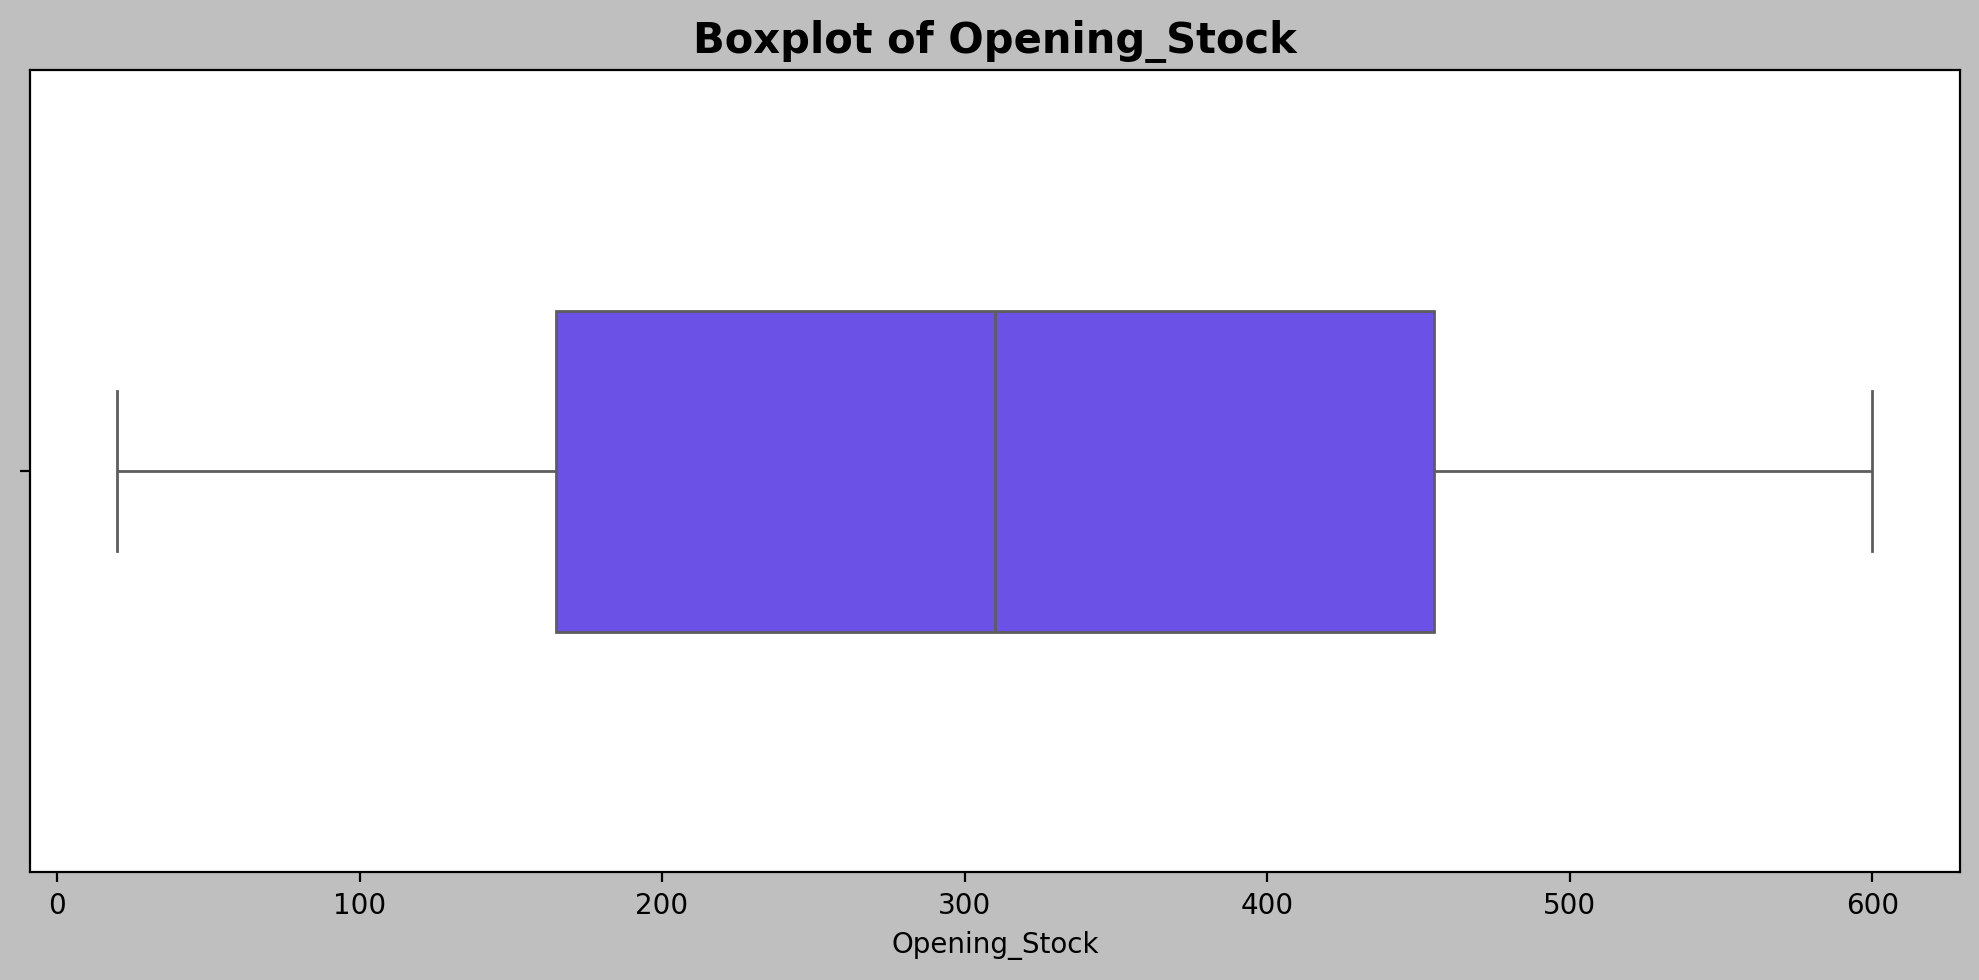

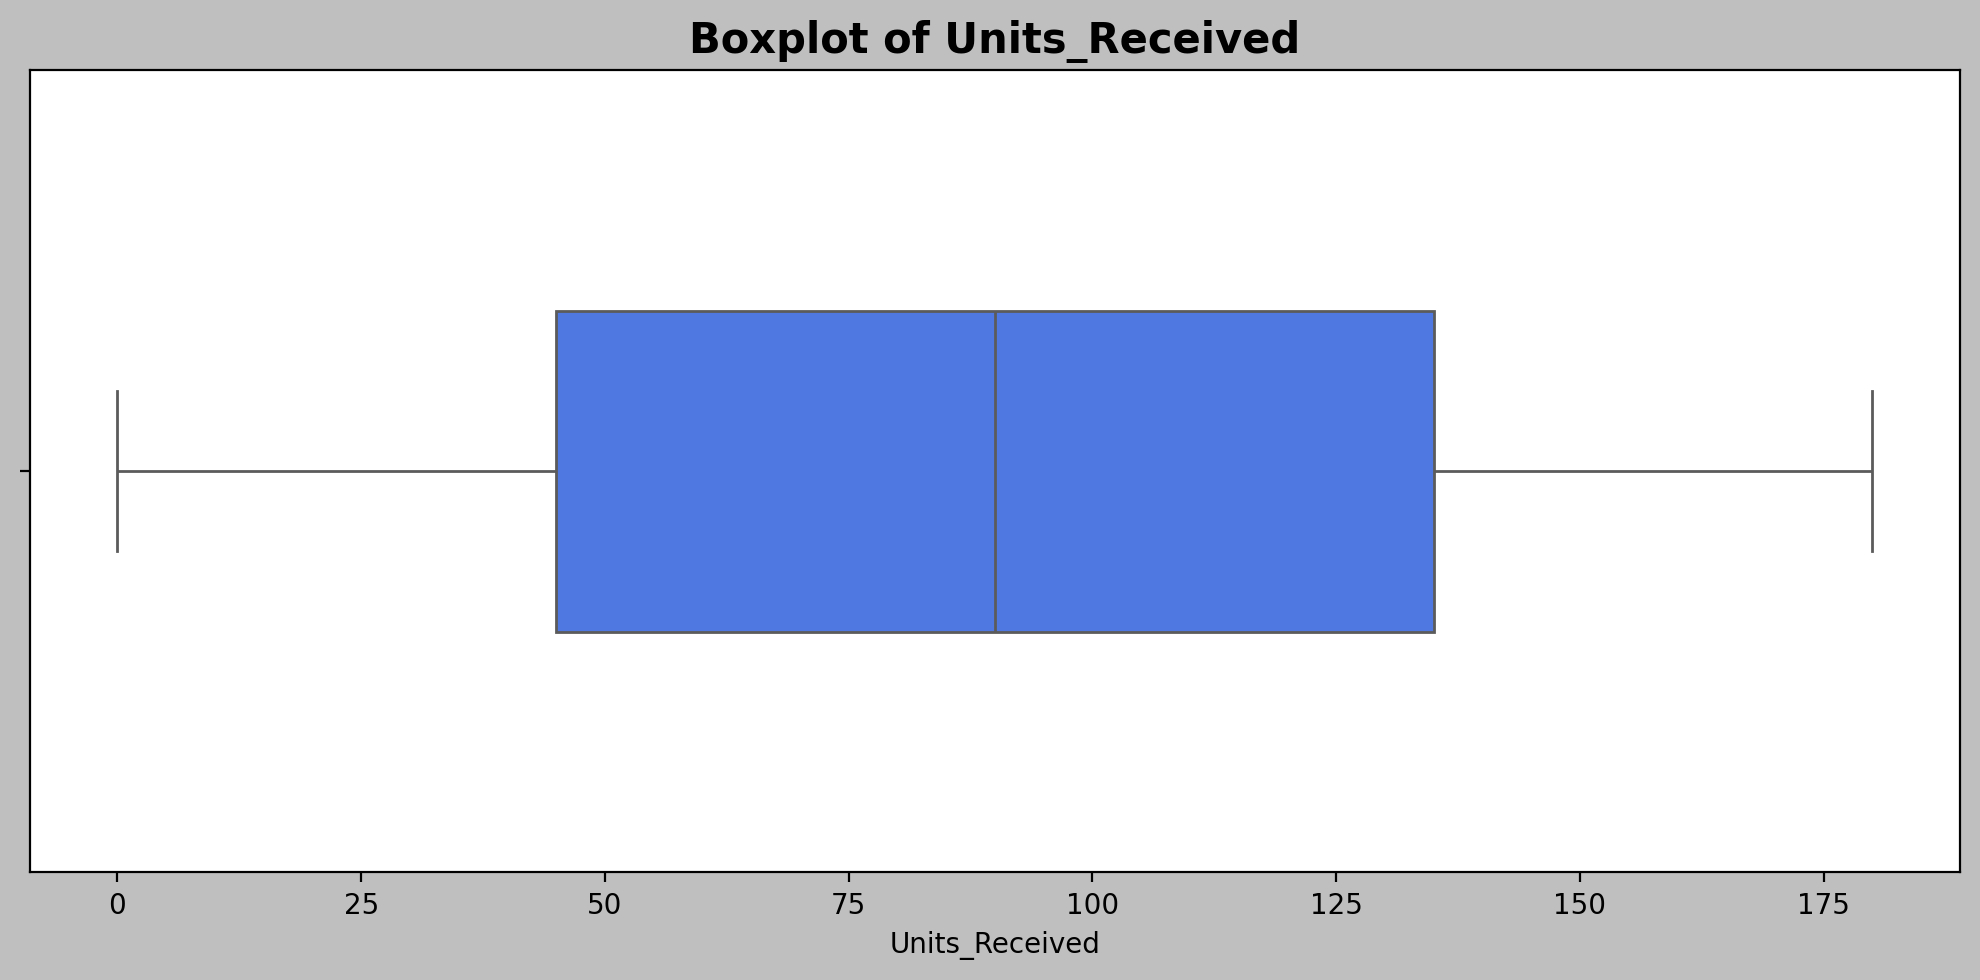

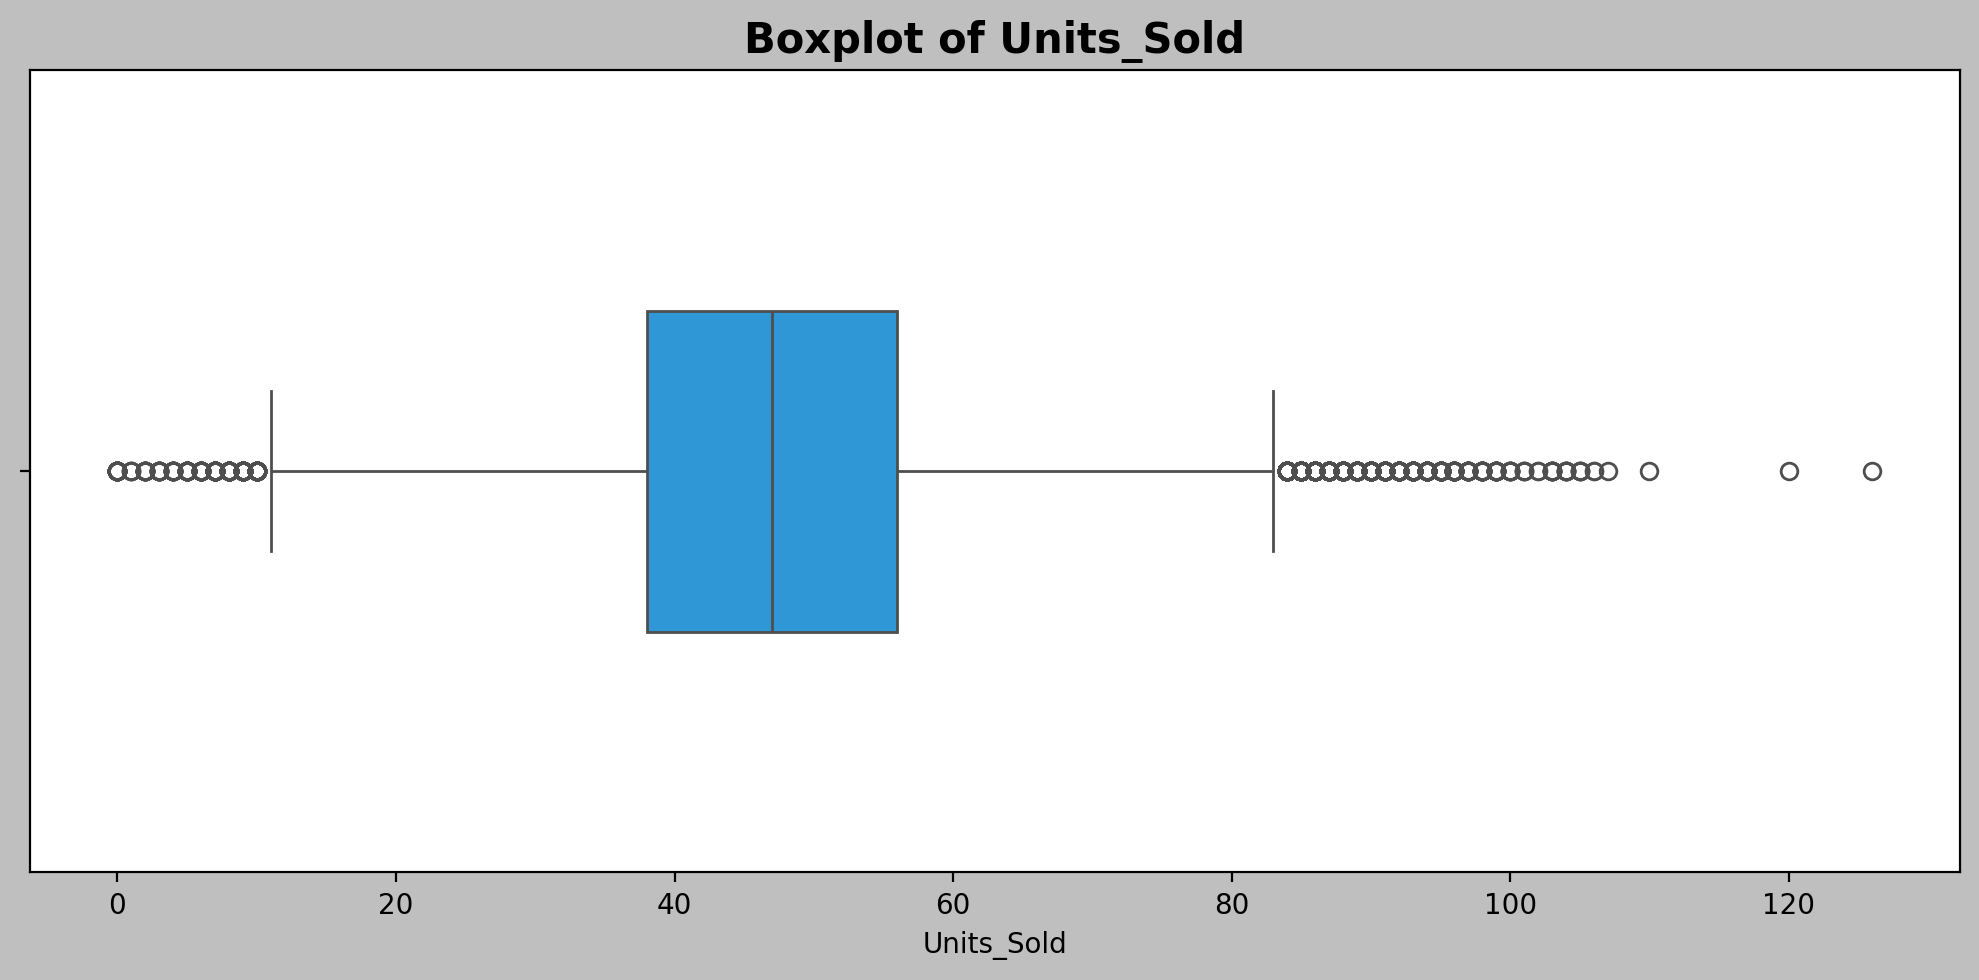

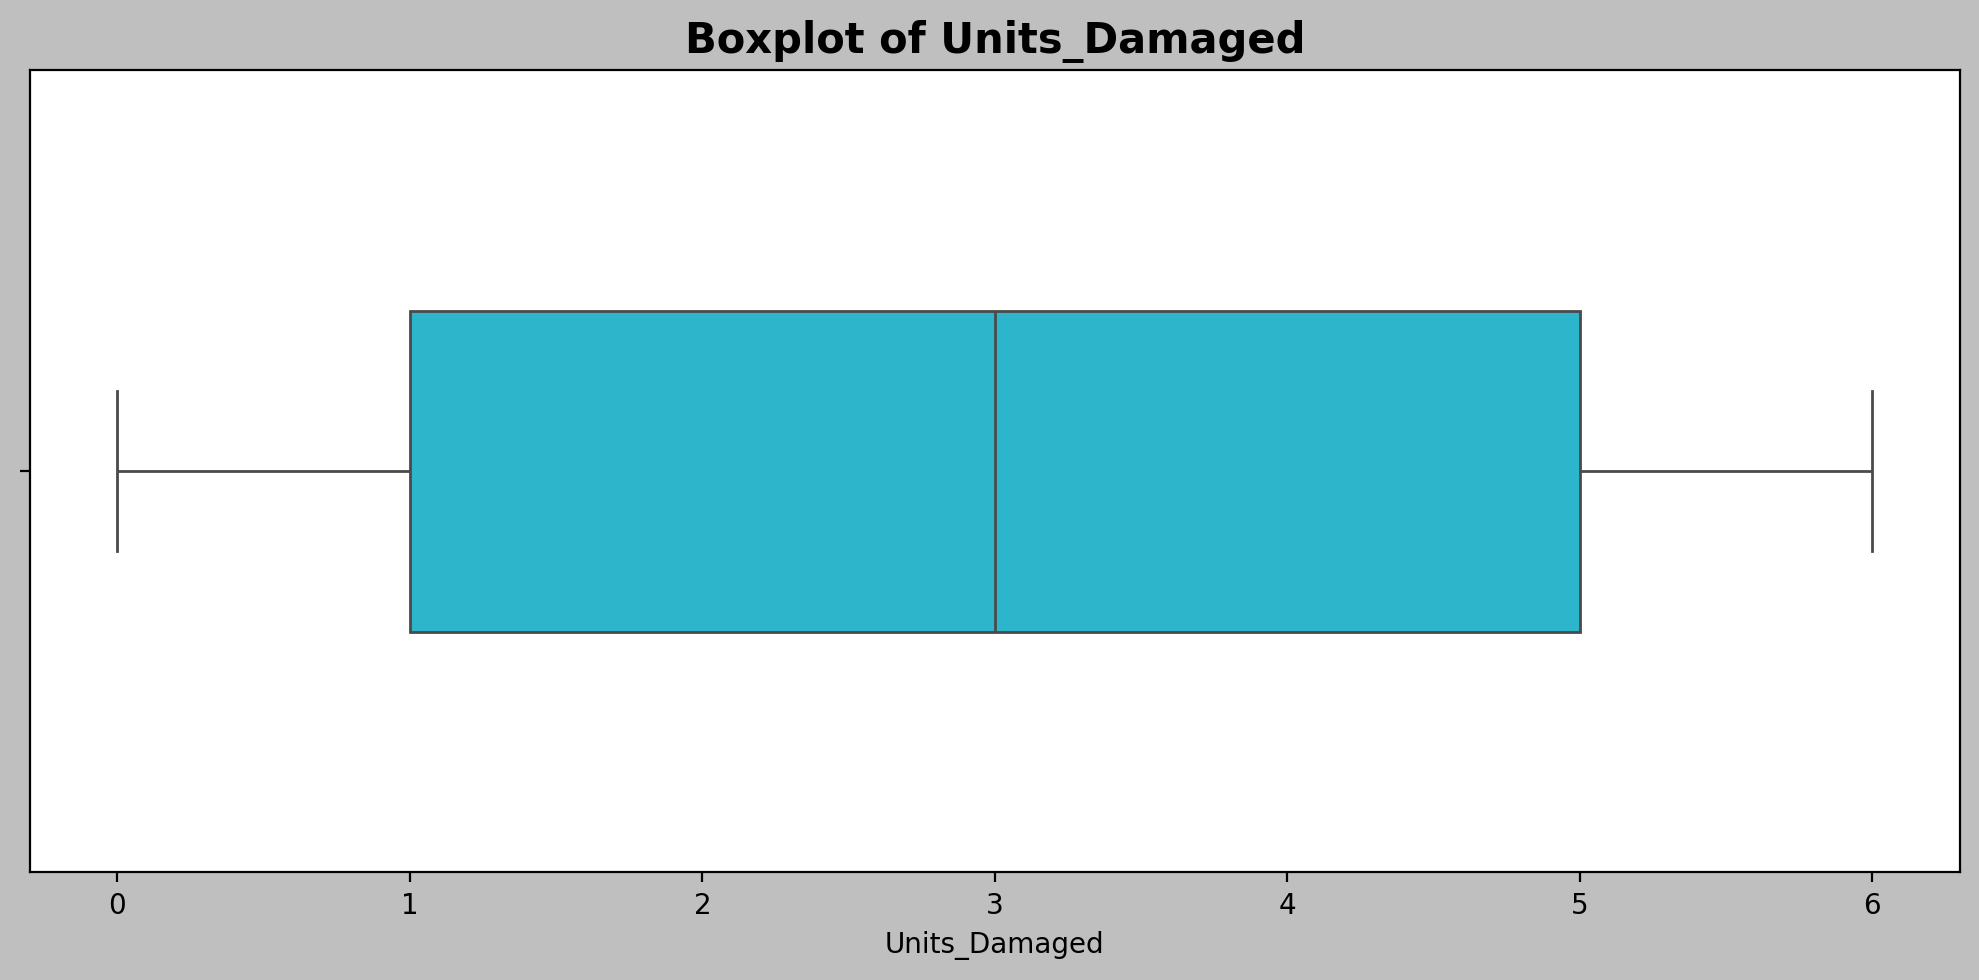

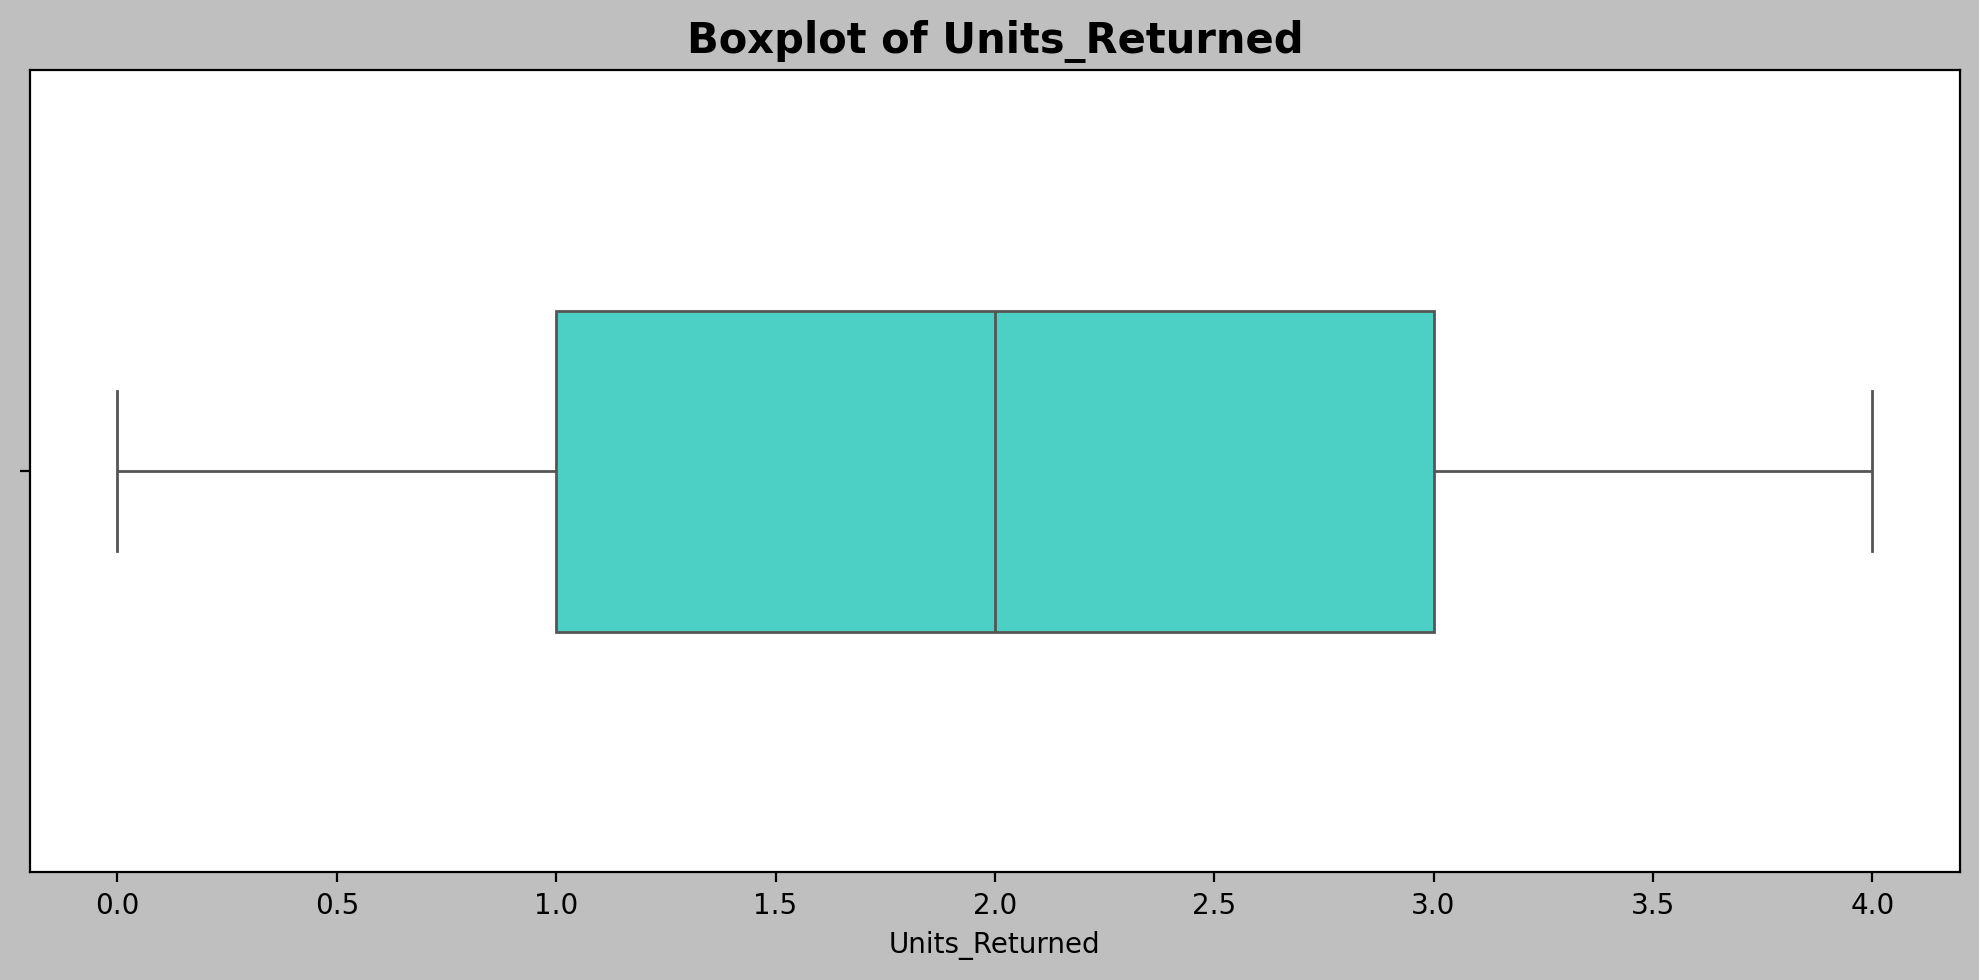

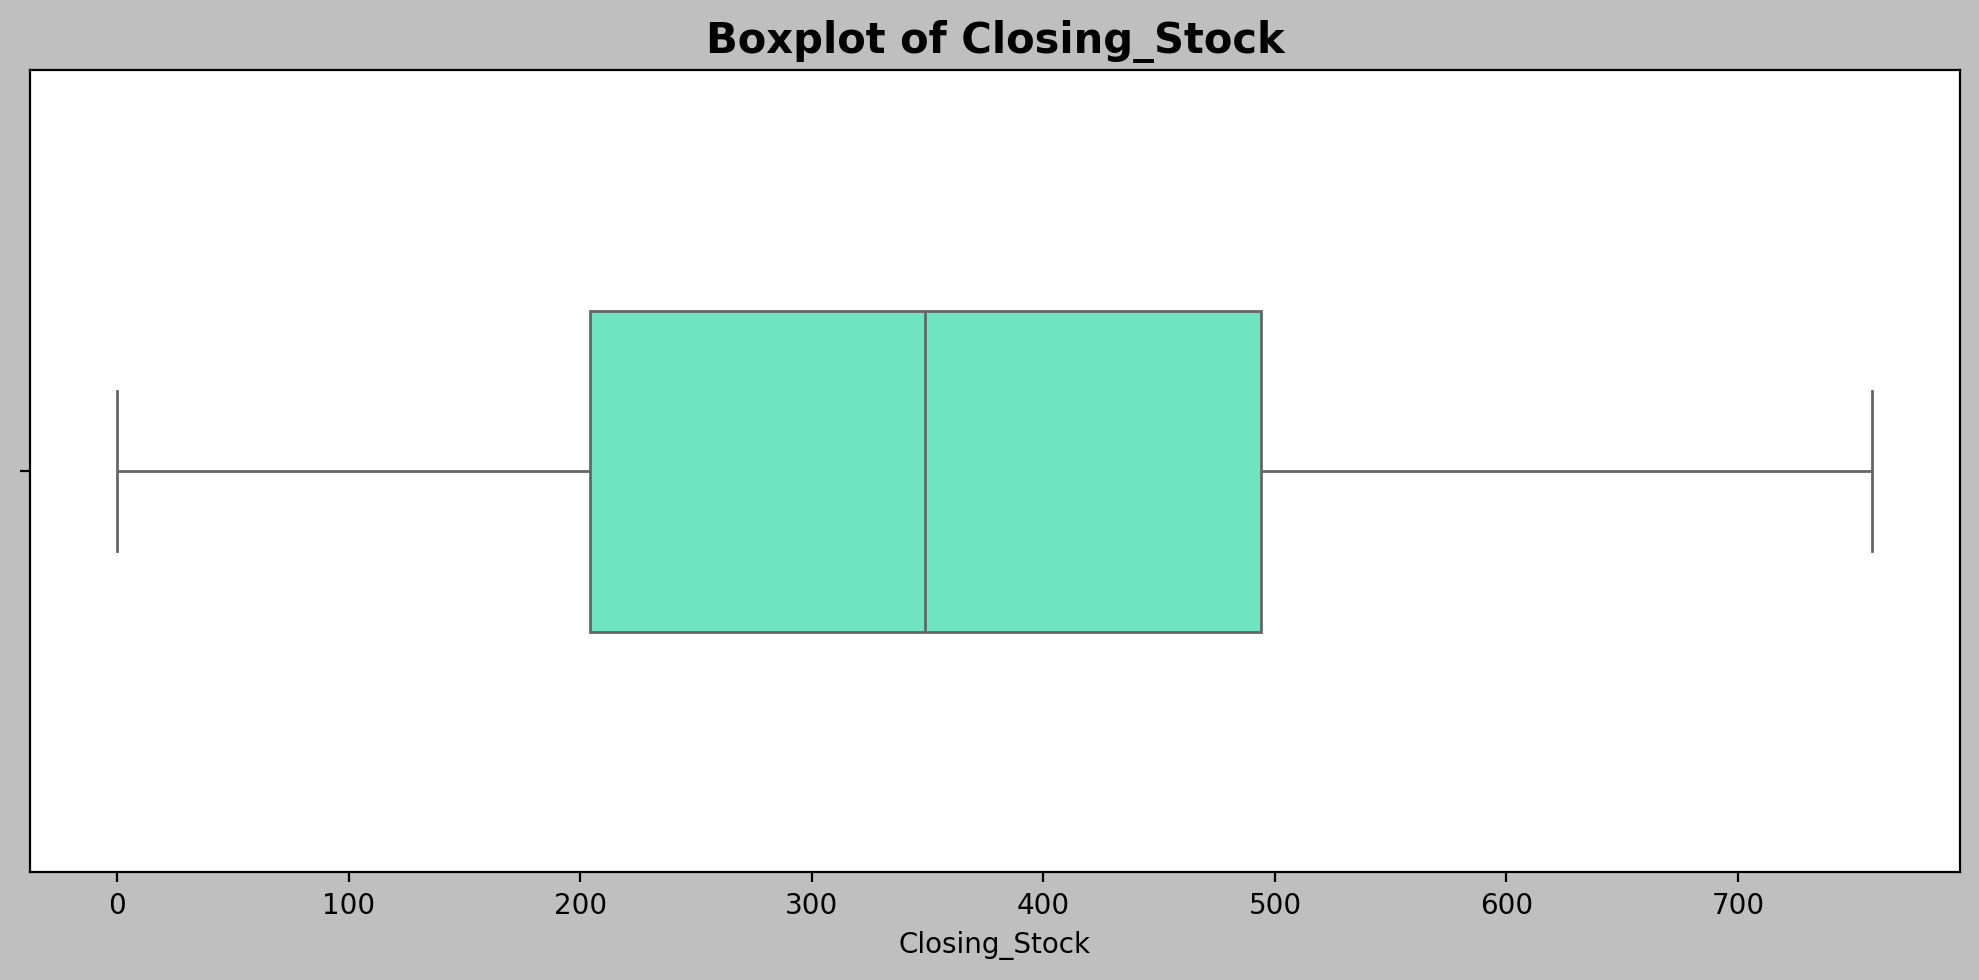

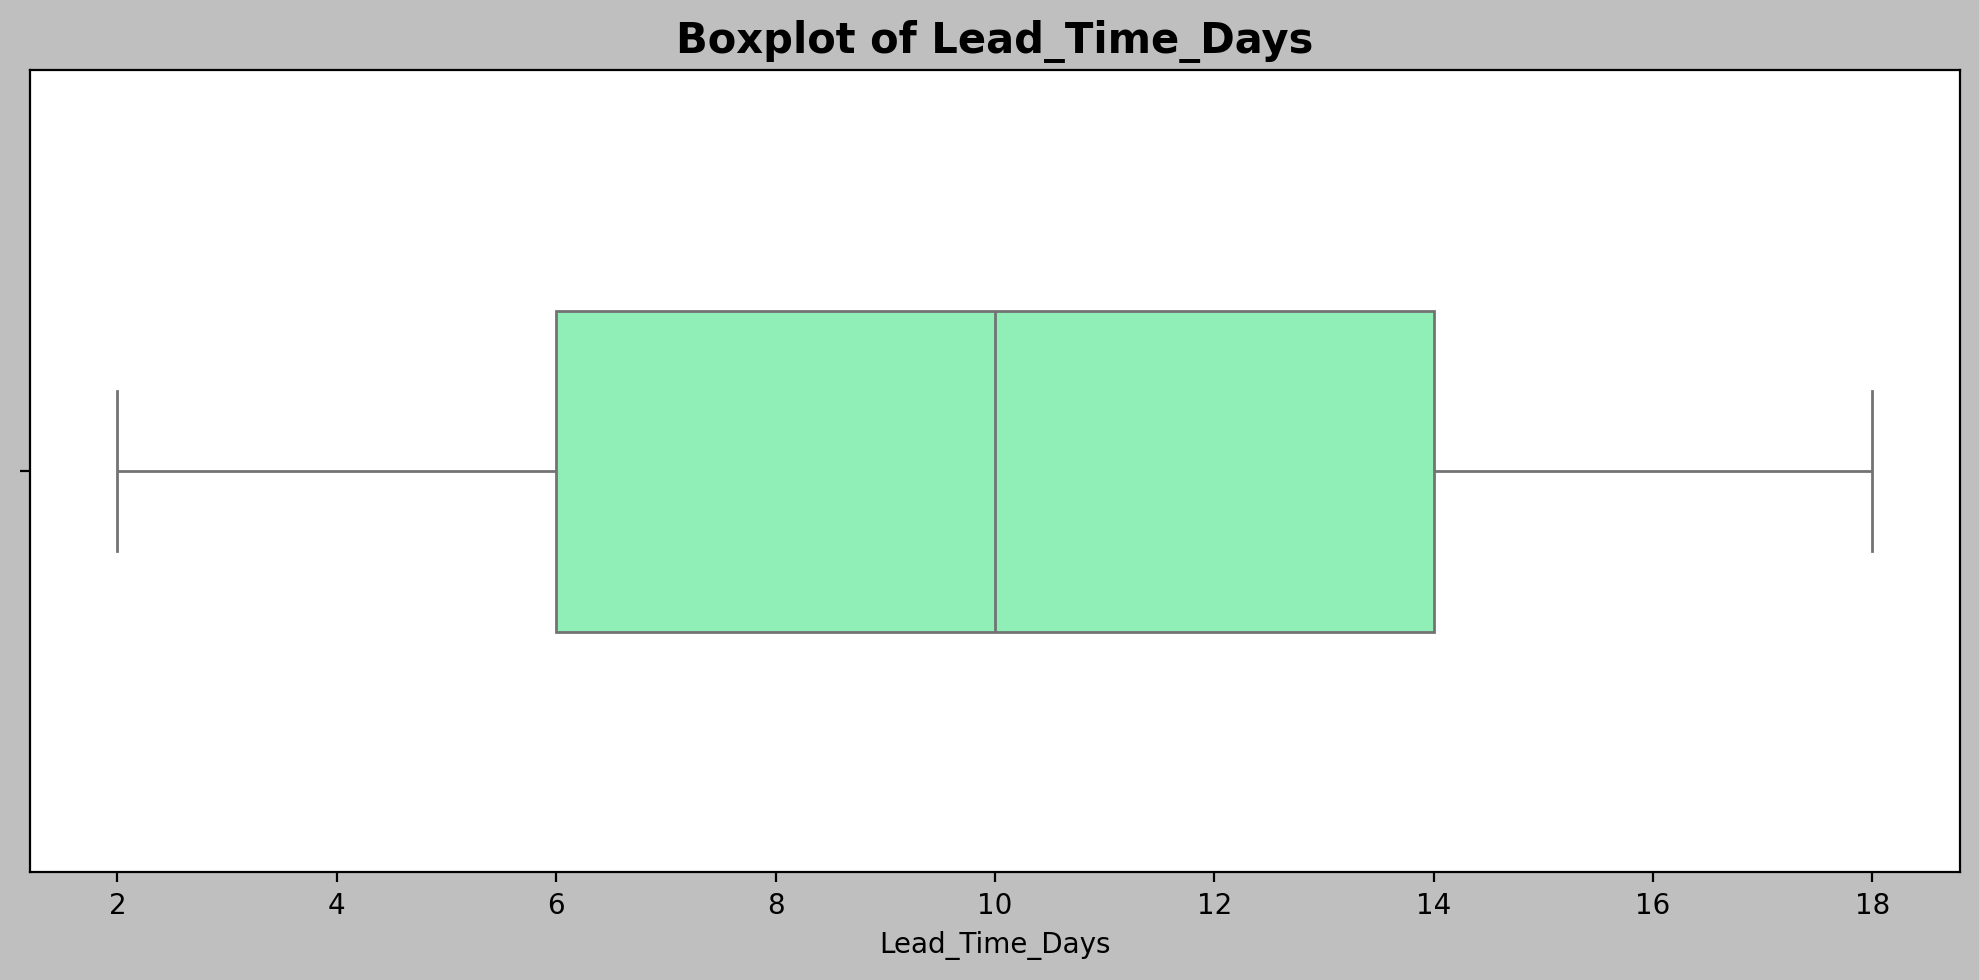

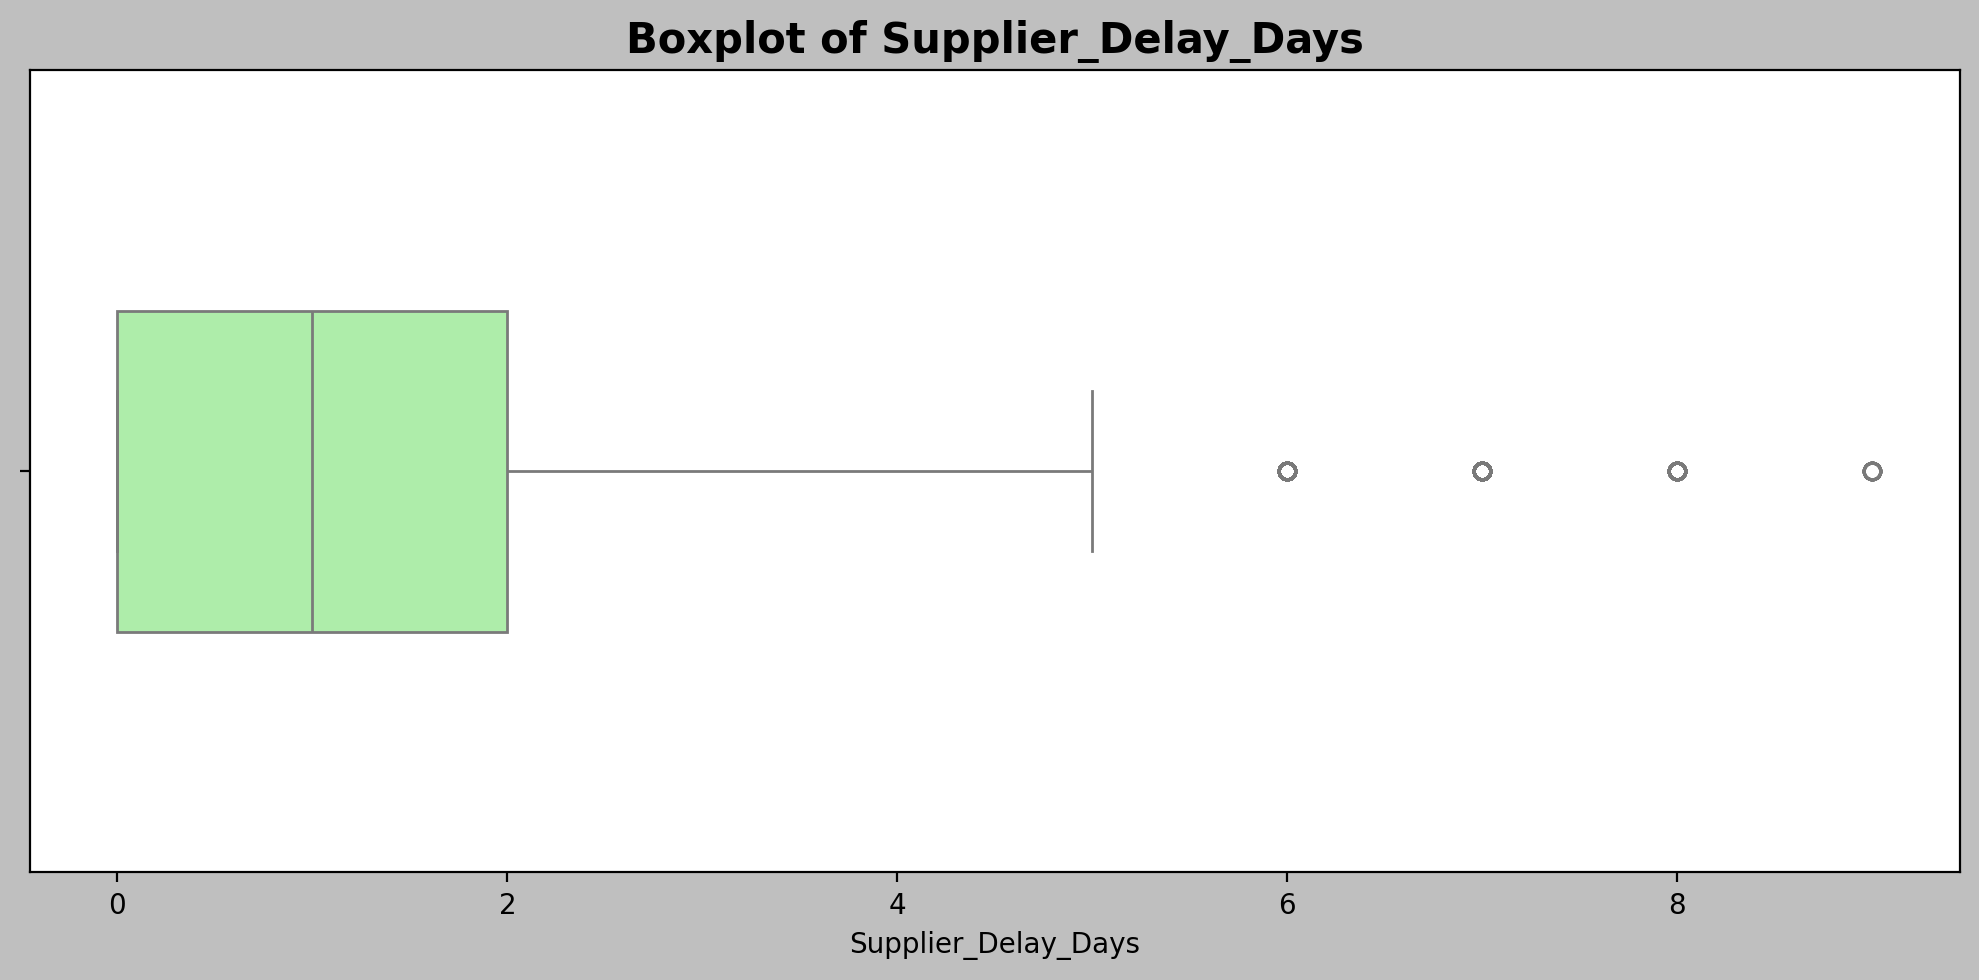

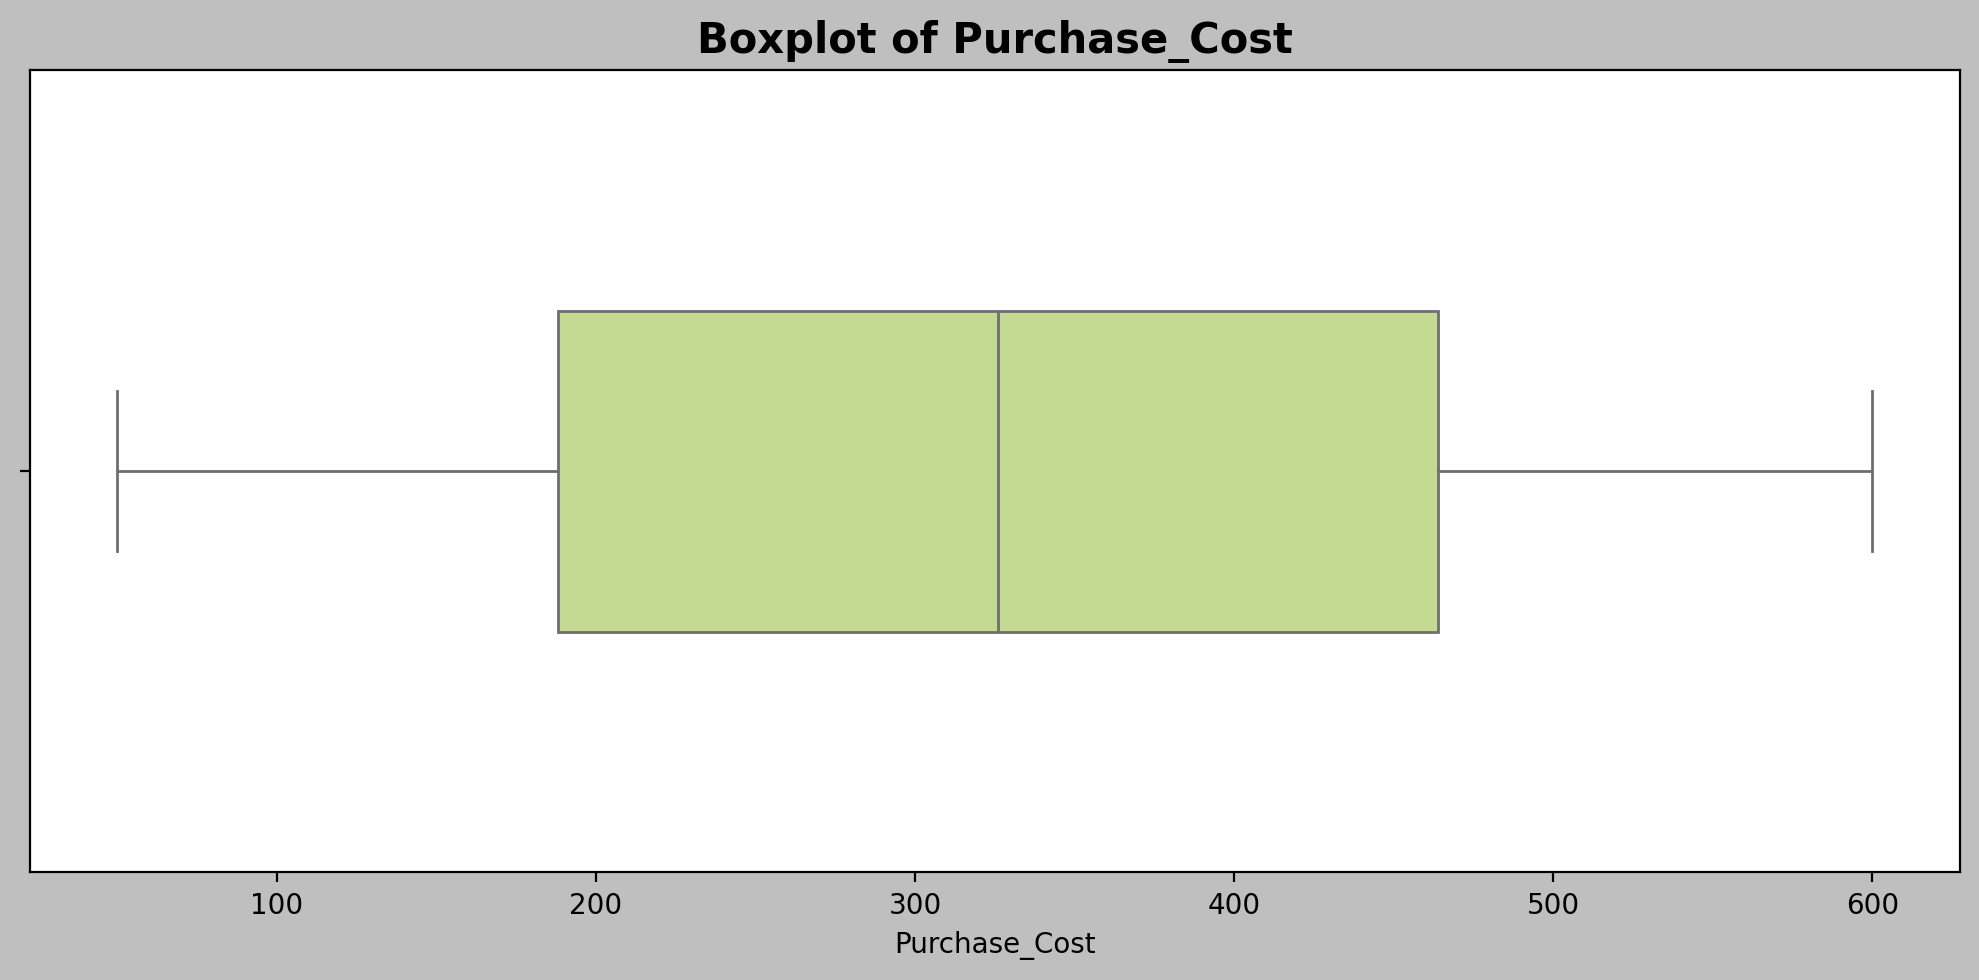

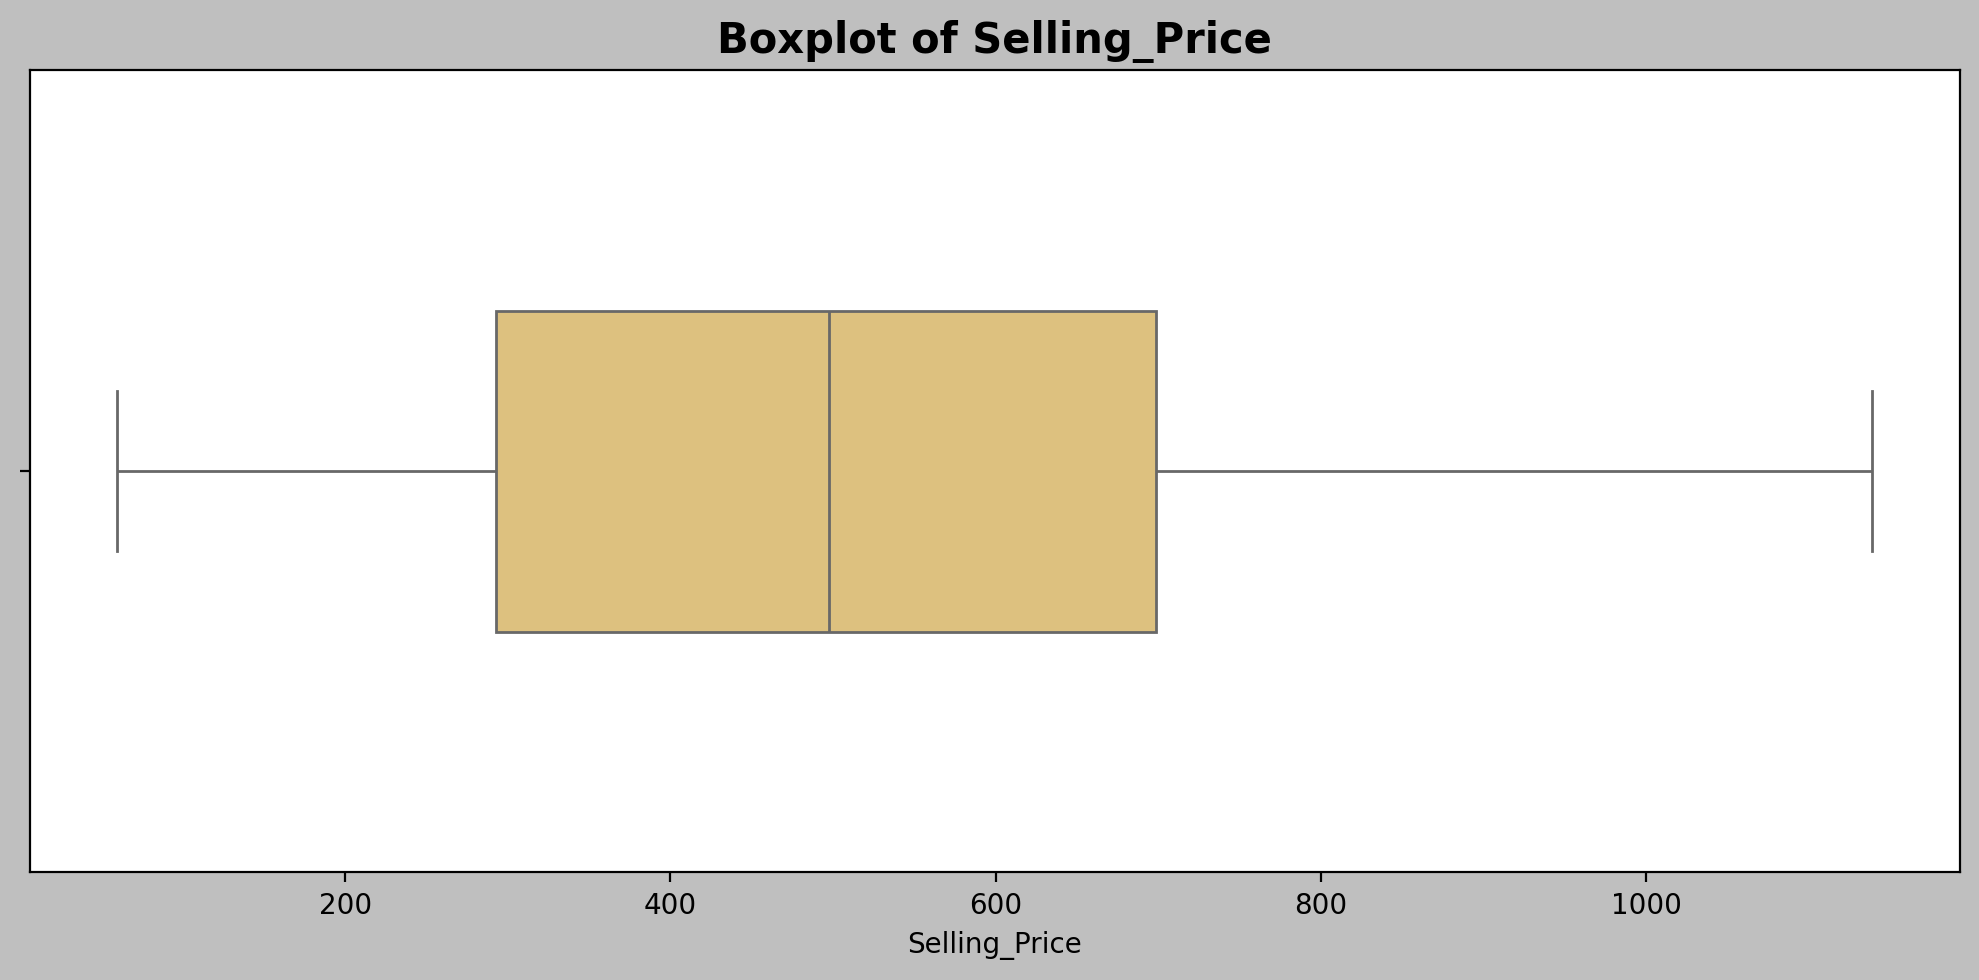

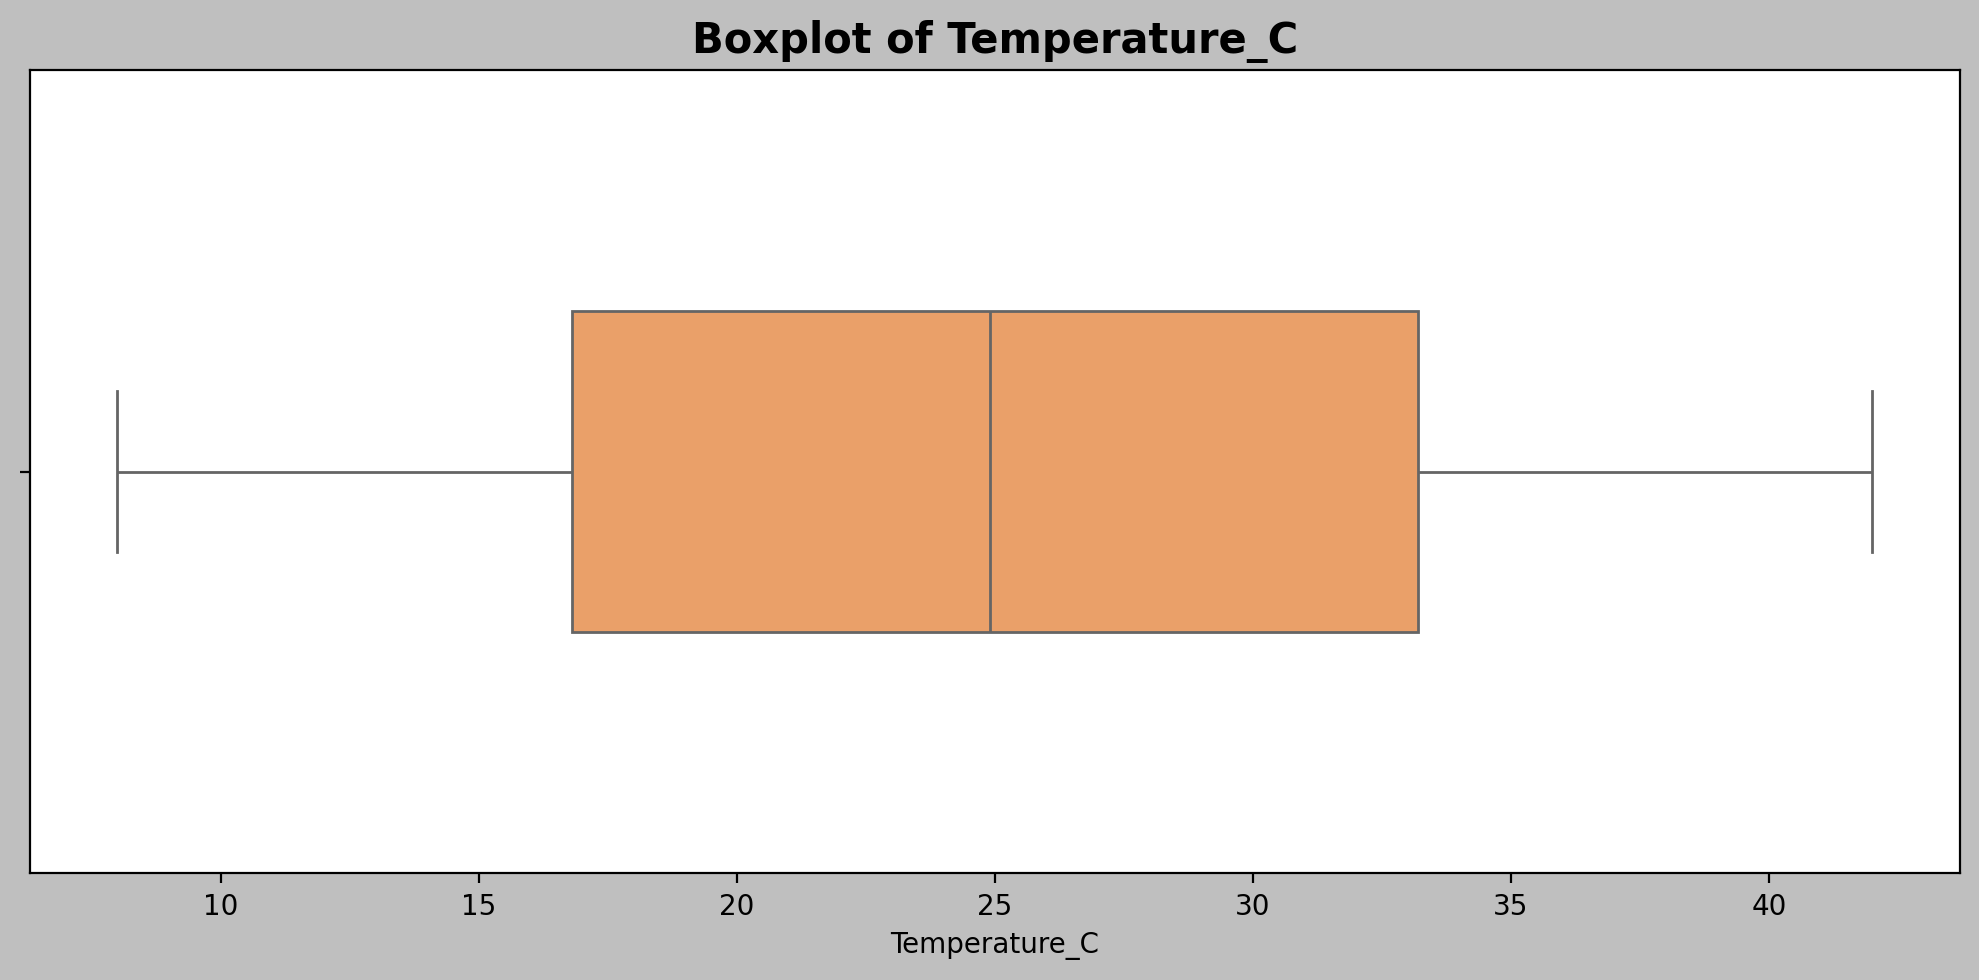

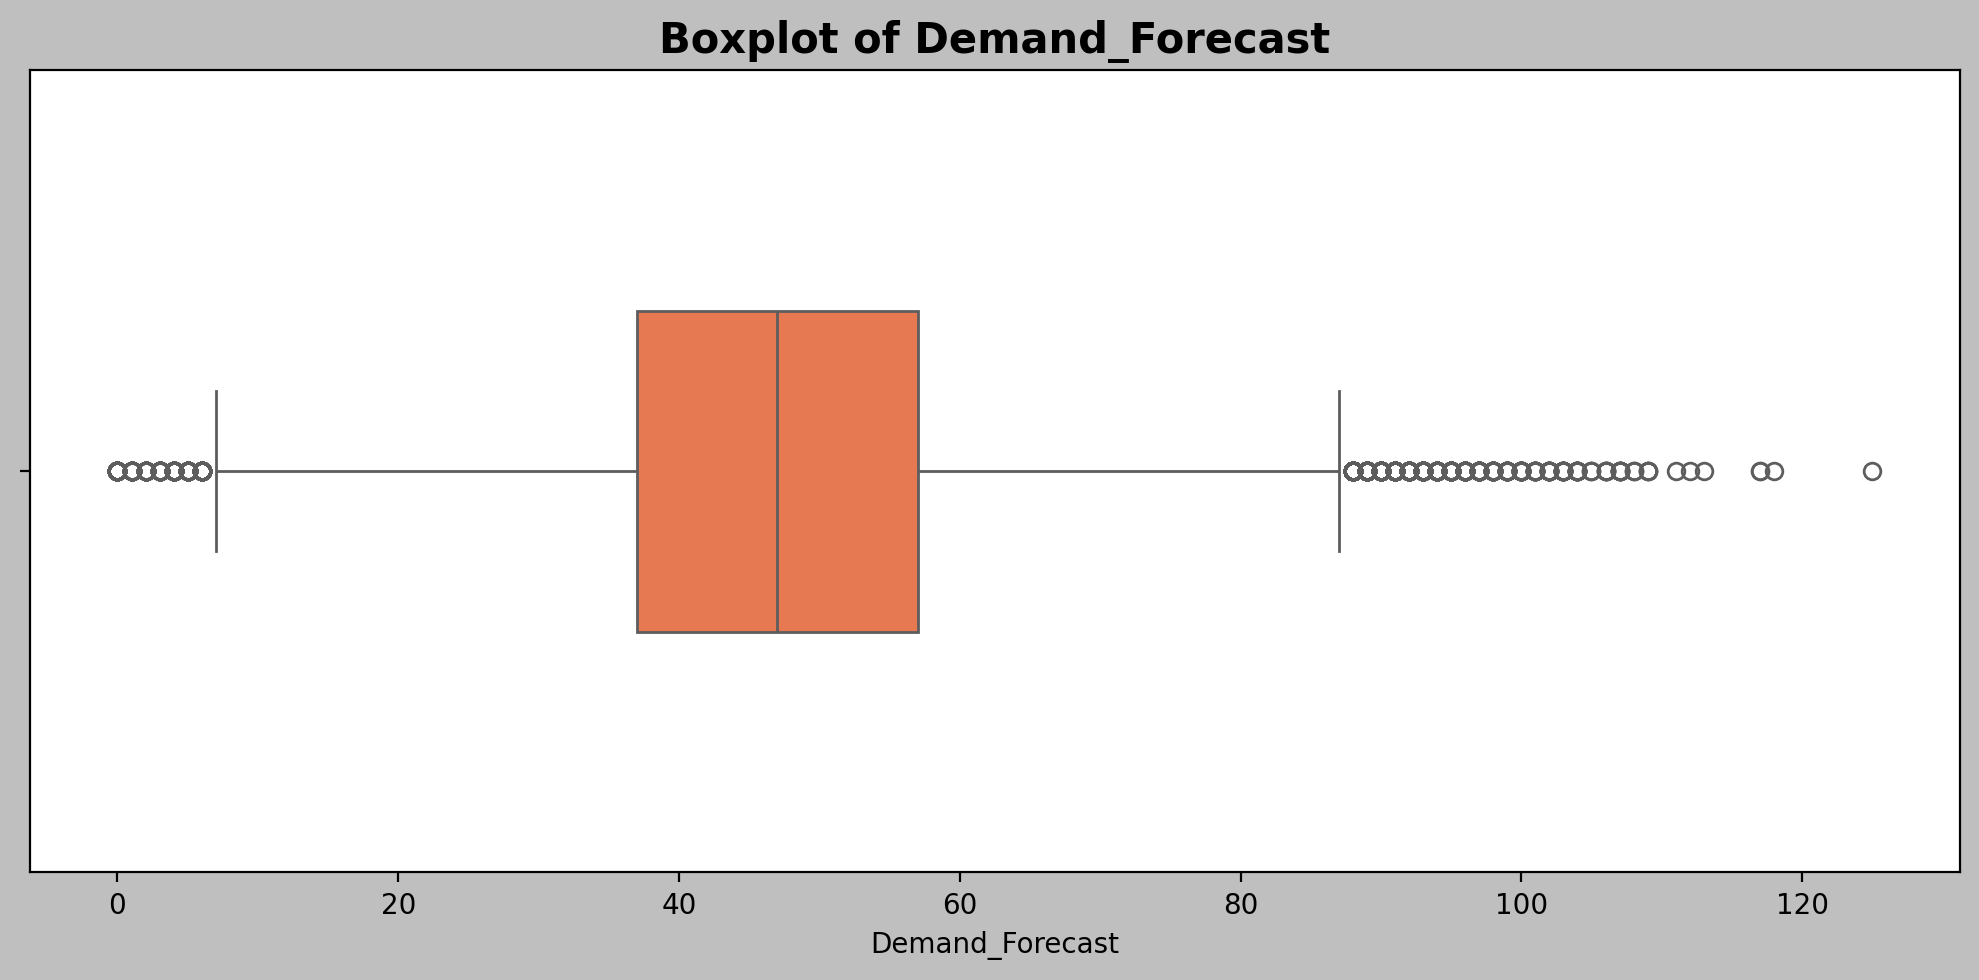

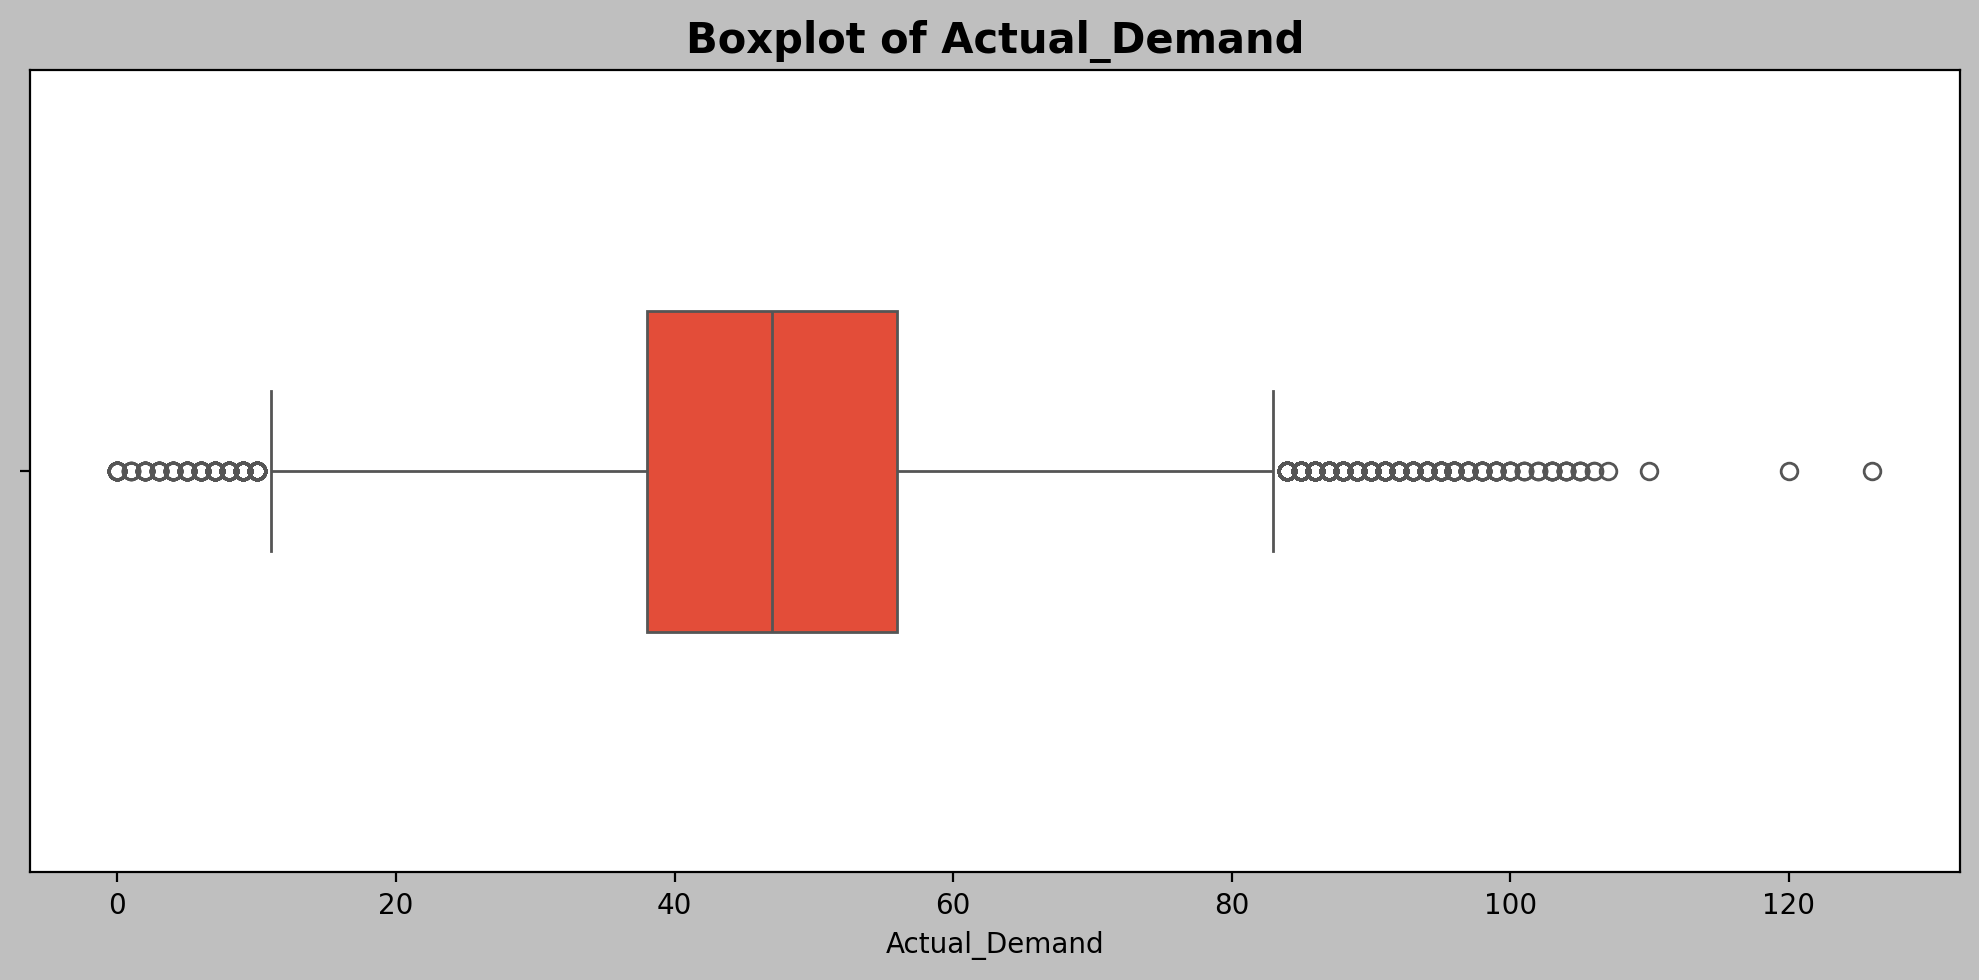

In [779]:
plt.style.use("grayscale")

numeric_columns = [
    "Opening_Stock",
    "Units_Received",
    "Units_Sold",
    "Units_Damaged",
    "Units_Returned",
    "Closing_Stock",
    "Lead_Time_Days",
    "Supplier_Delay_Days",
    "Purchase_Cost",
    "Selling_Price",
    "Temperature_C",
    "Demand_Forecast",
    "Actual_Demand"
]

colors = sns.color_palette("rainbow", len(numeric_columns))

for col, color in zip(numeric_columns, colors):

    plt.figure(figsize=(10,5), dpi=200)

    sns.boxplot(
        x=df[col],
        color=color,
        width=0.4
    )

    plt.title(f"Boxplot of {col}", fontsize=15, fontweight="bold")
    plt.xlabel(col)

    plt.tight_layout()
    plt.show()

In [424]:
numeric_columns = [
    "Opening_Stock",
    "Units_Received",
    "Units_Sold",
    "Units_Damaged",
    "Units_Returned",
    "Closing_Stock",
    "Lead_Time_Days",
    "Supplier_Delay_Days",
    "Purchase_Cost",
    "Selling_Price",
    "Temperature_C",
    "Demand_Forecast",
    "Actual_Demand"]

for col in numeric_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[
        (df[col] < lower) |
        (df[col] > upper)]
    print(f"{col} : {len(outliers)}")

Opening_Stock : 0
Units_Received : 0
Units_Sold : 1961
Units_Damaged : 0
Units_Returned : 0
Closing_Stock : 0
Lead_Time_Days : 0
Supplier_Delay_Days : 2341
Purchase_Cost : 0
Selling_Price : 0
Temperature_C : 0
Demand_Forecast : 1560
Actual_Demand : 1985


In [425]:
df.shape

(200000, 29)

In [426]:
outliers["Units_Sold"].shape[0]

1985

In [427]:
summary = []

for col in numeric_columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_count = df[
        (df[col] < lower) |
        (df[col] > upper)
    ].shape[0]

    percentage = (outlier_count / len(df)) * 100

    summary.append([
        col,
        outlier_count,
        round(percentage,2)
    ])

outlier_summary = pd.DataFrame(
    summary,
    columns=[
        "Column",
        "Outlier_Count",
        "Outlier_Percentage"
    ]
)

outlier_summary.sort_values(
    by="Outlier_Percentage",
    ascending=False
)

,Column,Outlier_Count,Outlier_Percentage
7,Supplier_Delay_Days,2341,1.17
12,Actual_Demand,1985,0.99
2,Units_Sold,1961,0.98
11,Demand_Forecast,1560,0.78
0,Opening_Stock,0,0.00
1,Units_Received,0,0.00
3,Units_Damaged,0,0.00
4,Units_Returned,0,0.00
5,Closing_Stock,0,0.00
6,Lead_Time_Days,0,0.00


Outliers were detected using the IQR method. However, after business validation, they were retained
because they represent genuine operational events such as demand spikes, supplier delays, and seasonal 
fluctuations rather than data quality issues.

# ***Exploratory Data Analysis***

## Section A — Inventory Health

# Q1. How is inventory changing over time?

Date
1     5950891
2     5481260
3     5881708
4     5751904
5     5937457
6     5746440
7     5960151
8     5875418
9     5771371
10    5923326
11    5766100
12    5853445
Name: Closing_Stock, dtype: int64


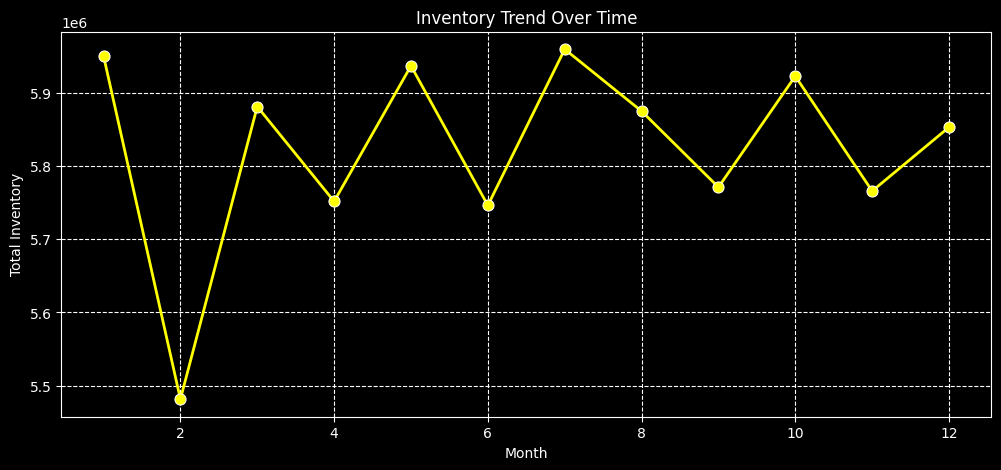

In [514]:
monthly_inventory = df.groupby(df['Date'].dt.month)['Closing_Stock'].sum()
print(monthly_inventory)
plt.figure(figsize=(12,5))
plt.style.use("dark_background")
sns.lineplot(
    x=monthly_inventory.index,
    y=monthly_inventory.values,
    marker="o",
    markersize=8,
    linewidth=2, color="yellow"
)

plt.title("Inventory Trend Over Time")
plt.xlabel("Month")
plt.ylabel("Total Inventory")
plt.grid(True,linestyle="--")

plt.show()

Monthly inventory levels show how stock is moving throughout the year. A rising trend indicates inventory accumulation, while a declining trend indicates inventory consumption."

##### If Trend is Increasing:-
* Inventory accumulation is happening.
* Overstock risk may increase.
* Warehouse costs may rise.

#####  If Trend is Decreasing:-
* Strong sales performance.
* Potential stock-out risk.
* Replenishment planning required.

##### Recommendation-
* Inventory is showing a downward trend over the last period, indicating higher product movement. Procurement planning should be reviewed to avoid future stock shortages.

# Q2 Which warehouses are frequently running out of stock?

C:\Users\richa\AppData\Local\Temp\ipykernel_2224\286342058.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(warehouse_stockout,palette="plasma")


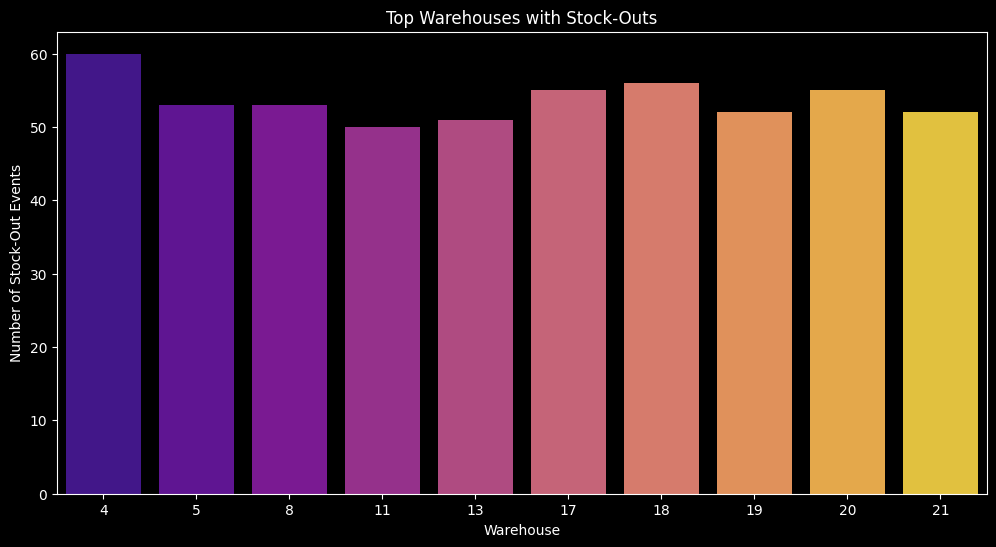

In [528]:
stockout_df = df[df["Closing_Stock"] == 0]

warehouse_stockout = (
    stockout_df.groupby("Warehouse_ID")
    .size()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(warehouse_stockout,palette="plasma")


plt.title("Top Warehouses with Stock-Outs")
plt.xlabel("Warehouse")
plt.ylabel("Number of Stock-Out Events")
plt.show()

* If inventory consistently increases month after month, the company may be purchasing more products than customers are demanding.

##### Business Impact
* Higher warehouse costs
* Increased holding costs
* Risk of product expiry
* Blocked working capital


##### Business Insights
* High Stock-out Warehouses
* Poor inventory planning.
* Demand forecasting issues.
* Delayed supplier deliveries.

##### Recommendation

* Warehouse W12 and W08 contribute the highest stock-out incidents. These locations should be prioritized for inventory review and demand forecasting improvements.

# Q3 Which Product require immediate replenishment ?

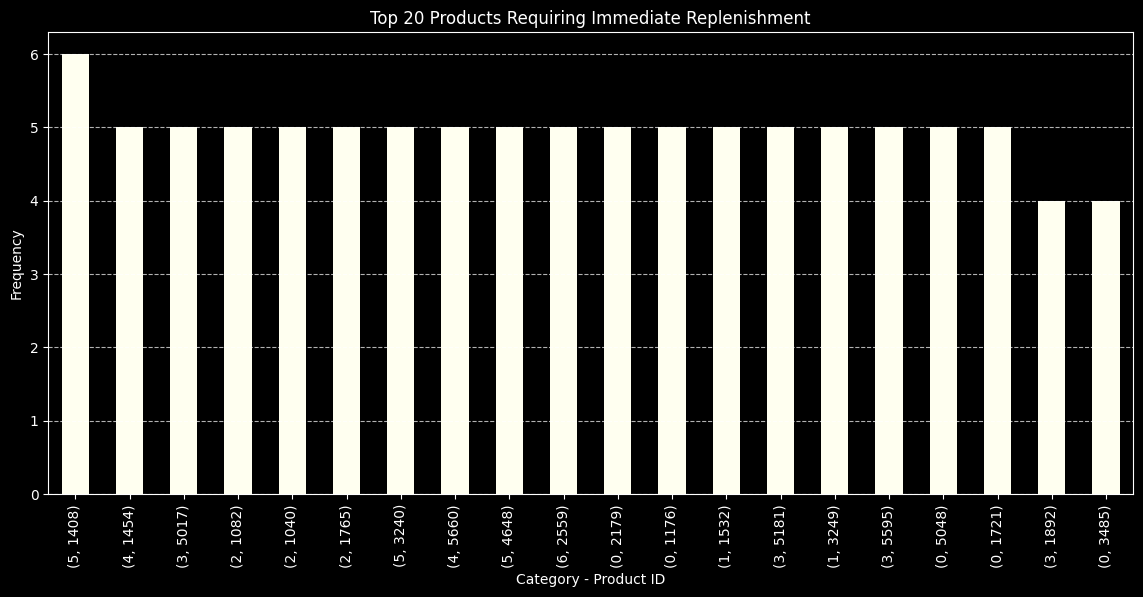

In [538]:
replenishment = df[
    df["Closing_Stock"] <= df["Reorder_Level"]
]


product_replenishment = (
    replenishment.groupby(["Category", "Product_ID"])
    .size()
    .sort_values(ascending=False)
    .head(20)
)
plt.figure(figsize=(14,6))
product_replenishment.plot(kind="bar",color="ivory")

plt.title("Top 20 Products Requiring Immediate Replenishment")
plt.xlabel("Category - Product ID")
plt.ylabel("Frequency")
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

##### Observation
* Product IDs 1408, 1454, and 5017 appear most frequently in the replenishment list.

##### Insight
* These products repeatedly reach the reorder threshold and require closer inventory monitoring.

##### Recommendation
* Review demand trends, reorder points, and supplier lead times to minimize stock-out risk and improve inventory availability.

# Q4. Which products have excess inventory? Client Pain-Overstock

C:\Users\richa\AppData\Local\Temp\ipykernel_2224\2478016568.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(overstock_products,palette="gist_rainbow_r")


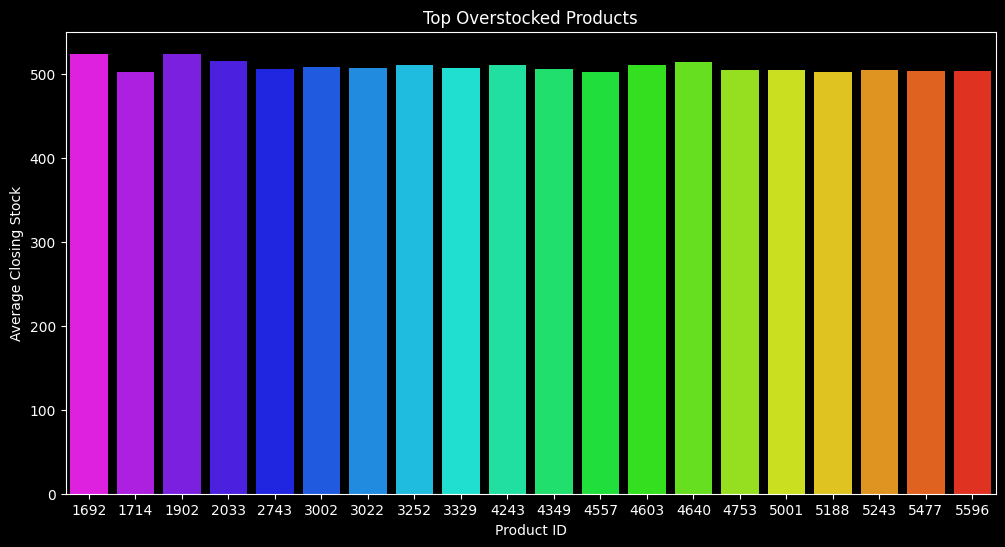

In [540]:
overstock = df[
    df["Closing_Stock"] > (2 * df["Reorder_Level"])
]

overstock_products = (
    overstock.groupby("Product_ID")["Closing_Stock"]
    .mean()
    .sort_values(ascending=False)
    .head(20)
)

plt.figure(figsize=(12,6))

sns.barplot(overstock_products,palette="gist_rainbow_r")
plt.title("Top Overstocked Products")
plt.xlabel("Product ID")
plt.ylabel("Average Closing Stock")
plt.show()

##### Observation
* The top overstocked products(led by Product IDs 1902 and 1692) consistenly maintain a high average closing stock aove 500 units across the board.

##### Insight
* Excess inventory is tied up uniformly across multiple SKUs, indicating widerspread over-forecasting or poor inventory turnover that locks up working capital.

##### Recommendation
* implement targeted promotional discounts, bundle sales, or temporarily halt reorders for these specific SKUs to clear surplus inventory and reduce carrying costs.

# Q5. Which products are below their safety stock? Client Pain-Inventory Risk

C:\Users\richa\AppData\Local\Temp\ipykernel_2224\3634774653.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(risk_summary,palette="cool")


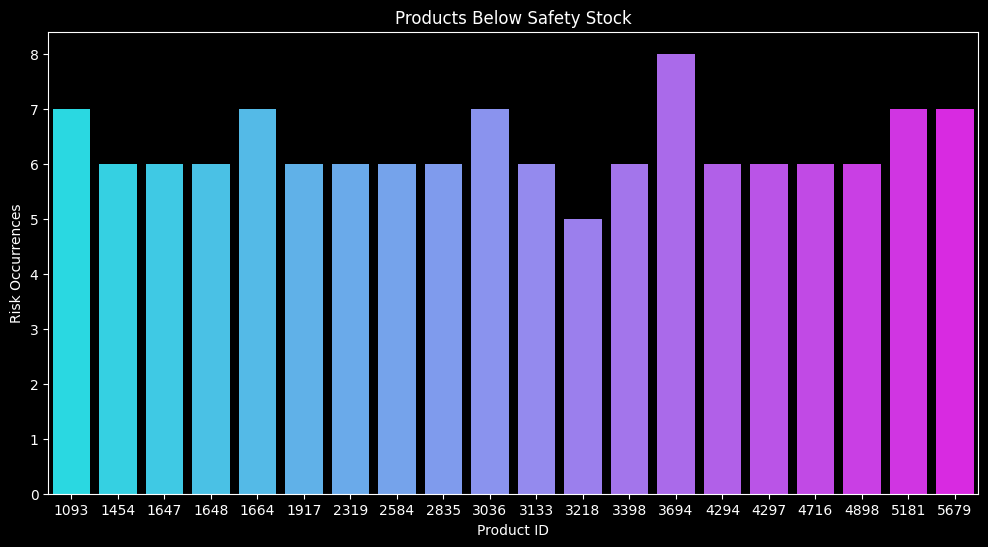

In [548]:
risk_products = df[
    df["Closing_Stock"] < df["Safety_Stock"]    
]

risk_summary = (
    risk_products.groupby("Product_ID")
    .size()
    .sort_values(ascending=False)
    .head(20)
)

plt.figure(figsize=(12,6))

sns.barplot(risk_summary,palette="cool")

plt.title("Products Below Safety Stock")
plt.xlabel("Product ID")
plt.ylabel("Risk Occurrences")
plt.show()

##### Observation: 
* Product 3694 ran dangerously low on stock 8 different times, and many other items ran low 5 to 7 times.

##### Insight: 
* These products are selling out faster than they are being replaced, which puts you at risk of turning away buying customers.

##### Recommendation: 
* Order fresh stock for these items immediately and increase their minimum stock limits so you don't run out again.

# Q6)  Which suppliers are causing the highest delivery delays? Client Pain- Supplier Performance


In [448]:
supplier_delay = (df.groupby("Supplier_ID").agg(
          Total_Orders=("Supplier_ID","count"),
          Avg_Delay=("Supplier_Delay_Days","mean"),
          Max_Delay=("Supplier_Delay_Days","max"),
          Total_Delay=("Supplier_Delay_Days","sum")
      )
      .reset_index()
)

supplier_delay = supplier_delay.sort_values(
    by="Avg_Delay",
    ascending=False
)

print(supplier_delay.head(10))

     Supplier_ID  Total_Orders  Avg_Delay  Max_Delay  Total_Delay
17            18          1588   1.486146        8.0       2360.0
54            55          1715   1.464723        8.0       2512.0
98            99          1719   1.461315        7.0       2512.0
61            62          1721   1.456711        7.0       2507.0
104          105          1679   1.455628        9.0       2444.0
13            14          1688   1.446682        8.0       2442.0
94            95          1691   1.439976        8.0       2435.0
90            91          1705   1.438710        7.0       2453.0
95            96          1622   1.430333        9.0       2320.0
86            87          1628   1.428133        8.0       2325.0


In [449]:
supplier_delay_freq = (
    df.assign(Delayed=df["Supplier_Delay_Days"]>0)
      .groupby("Supplier_ID")
      .agg(
          Delay_Frequency=("Delayed","mean")
      )
      .reset_index()
)

supplier_delay_freq["Delay_Frequency"]*=100

print(supplier_delay_freq.sort_values(
    by="Delay_Frequency",
    ascending=False
).head(10))

     Supplier_ID  Delay_Frequency
84            85        63.781461
104          105        63.668851
54            55        63.615160
111          112        63.481829
87            88        63.325330
92            93        63.287514
6              7        63.174404
71            72        63.085572
76            77        63.051251
44            45        63.013699


C:\Users\richa\AppData\Local\Temp\ipykernel_2224\3745464189.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10["Supplier_ID"].astype(str),


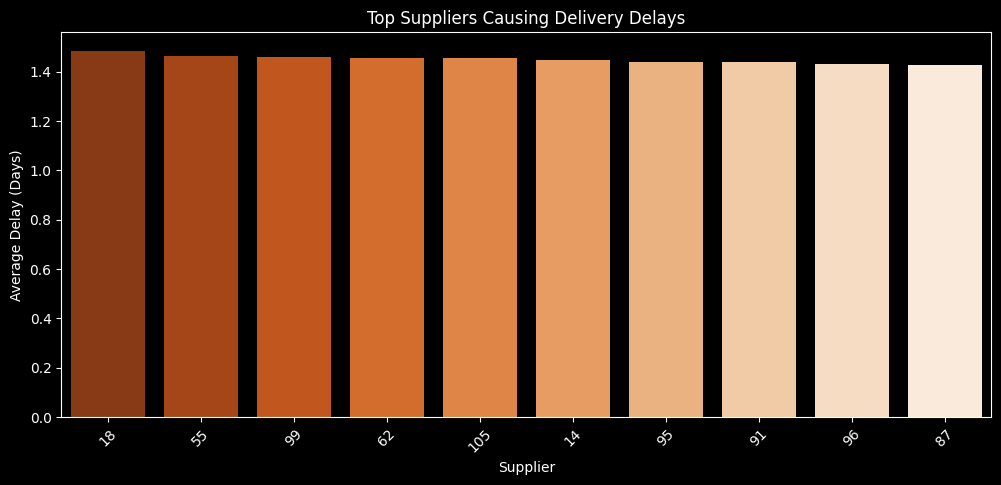

In [554]:
top10 = supplier_delay.head(10)
plt.figure(figsize=(12,5))

sns.barplot(x=top10["Supplier_ID"].astype(str),
        y=top10["Avg_Delay"],palette="Oranges_r")

plt.xticks(rotation=45)
plt.xlabel("Supplier")
plt.ylabel("Average Delay (Days)")
plt.title("Top Suppliers Causing Delivery Delays")
plt.show()

##### Observation: 
* Supplier 18 causes the longest average delivery delay, though all listed suppliers consistently delay orders by roughly 1.4 to 1.5 days.

##### Insight: 
* Late shipments are a widespread vendor issue rather than a problem isolated to just one supplier, which creates predictable bottlenecks in restock schedules.

##### Recommendation: 
* Talk to these key suppliers to tighten delivery timelines, or factor this ~1.5-day buffer into your ordering schedules to avoid stock running out.

# Q7.Is supplier delay increasing the risk of stock-outs? Client Pain- Inventory Disruption


In [453]:
df["Stockout_Risk"] = (
    df["Closing_Stock"] <= df["Safety_Stock"]
).astype(int)

risk = (
    df.groupby("Supplier_ID")
      .agg(
          Avg_Delay=("Supplier_Delay_Days","mean"),
          Stockout_Rate=("Stockout_Risk","mean")
      )
      .reset_index()
)

risk["Stockout_Rate"]*=100

risk

,Supplier_ID,Avg_Delay,Stockout_Rate
0,1,1.371955,3.802733
1,2,1.415269,3.065356
2,3,1.424372,3.551745
3,4,1.349555,4.035608
4,5,1.394595,3.723724
...,...,...,...
115,116,1.409174,3.914373
116,117,1.392965,3.456640
117,118,1.406842,4.764814
118,119,1.333333,3.480826


In [454]:
# Correlation matrix
corr = df[["Supplier_Delay_Days", "Stockout_Risk"]].corr()
corr

,Supplier_Delay_Days,Stockout_Risk
Supplier_Delay_Days,1.000000,-0.001729
Stockout_Risk,-0.001729,1.000000


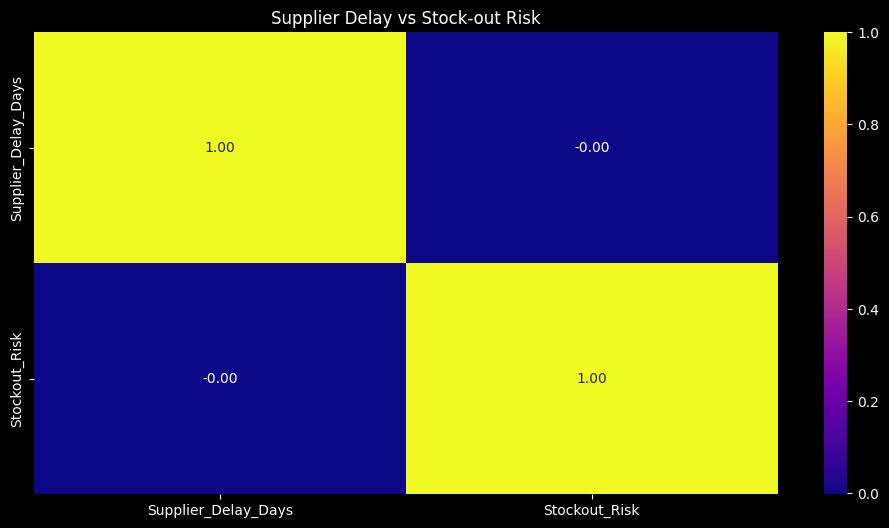

In [562]:
# Heatmap
plt.figure(figsize=(12,6))
sns.heatmap(corr, annot=True, cmap="plasma", fmt=".2f")
plt.title("Supplier Delay vs Stock-out Risk")
plt.show()

##### Observation: 
* The correlation value between Supplier_Delay_Days and Stockout_Risk is -0.00 (effectively 0).

##### Insight:
* Supplier delays are not the cause of your stock-out risks, as there is zero relationship between how late a supplier delivers and how often items go out of stock.

##### Recommendation:
* Shift your focus away from supplier delays and investigate internal factors like inaccurate sales forecasting, safety stock thresholds, or reorder point delays to fix the stock-out issues.

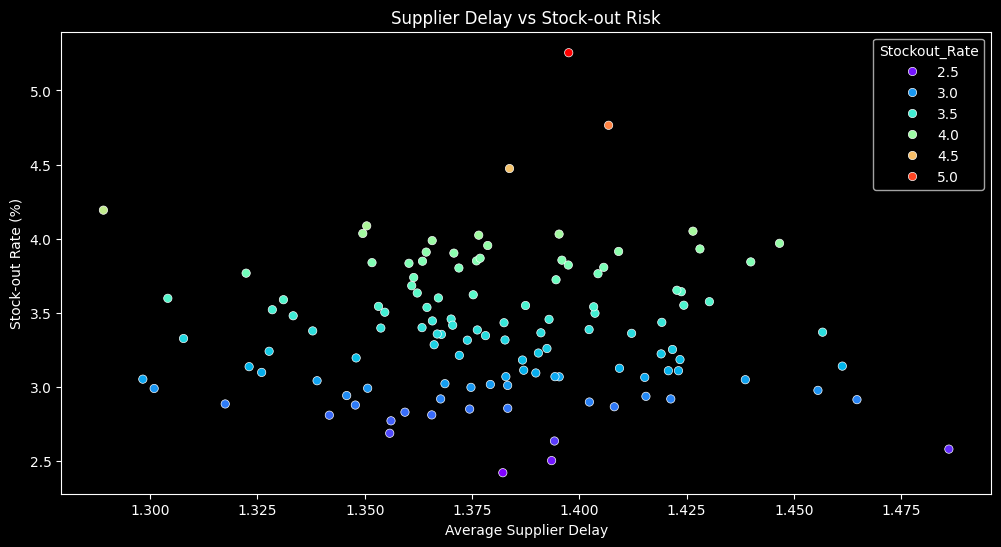

In [580]:
plt.figure(figsize=(12,6))

sns.scatterplot(
    data=risk,
    x="Avg_Delay",
    y="Stockout_Rate",
    hue="Stockout_Rate",
    palette="rainbow"
)

plt.xlabel("Average Supplier Delay")
plt.ylabel("Stock-out Rate (%)")
plt.title("Supplier Delay vs Stock-out Risk")

plt.show()

##### Observation: 
* The scatter plot shows a random cloud of data points without any upward or downward trend between supplier delays and stockout rates.

##### Insight: 
* Delays by suppliers do not impact or drive the stockout rate in this dataset.

##### Recommendation: 
* Investigate internal inventory metrics (like buffer stock thresholds or order lead times) rather than supplier timelines to manage stockout risks

## Q8.Which suppliers should be monitored or replaced? Client Pain- Vendor Management


In [460]:
supplier_score = (
    df.groupby("Supplier_ID")
      .agg(
          Avg_Delay=("Supplier_Delay_Days","mean"),
          Total_Orders=("Supplier_ID","count"),
          Avg_Lead_Time=("Lead_Time_Days","mean"),
          Stockout_Rate=("Stockout_Risk","mean")
      )
      .reset_index()
)

supplier_score["Stockout_Rate"]*=100
supplier_score

,Supplier_ID,Avg_Delay,Total_Orders,Avg_Lead_Time,Stockout_Rate
0,1,1.371955,1683,9.992870,3.802733
1,2,1.415269,1729,10.135338,3.065356
2,3,1.424372,1633,10.124923,3.551745
3,4,1.349555,1685,10.009496,4.035608
4,5,1.394595,1665,10.013213,3.723724
...,...,...,...,...,...
115,116,1.409174,1635,10.025076,3.914373
116,117,1.392965,1649,9.915706,3.456640
117,118,1.406842,1637,10.000611,4.764814
118,119,1.333333,1695,10.177581,3.480826


In [461]:
supplier_score["Risk_Score"] = (
      supplier_score["Avg_Delay"]*0.5
    + supplier_score["Avg_Lead_Time"]*0.2
    + supplier_score["Stockout_Rate"]*0.3
)

In [462]:
supplier_score["Risk_Score"]

0      3.825371
1      3.654309
2      3.802694
3      3.887359
4      3.817057
         ...   
115    3.883914
116    3.716616
117    4.132987
118    3.746431
119    3.713319
Name: Risk_Score, Length: 120, dtype: float64

C:\Users\richa\AppData\Local\Temp\ipykernel_2224\3950241612.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


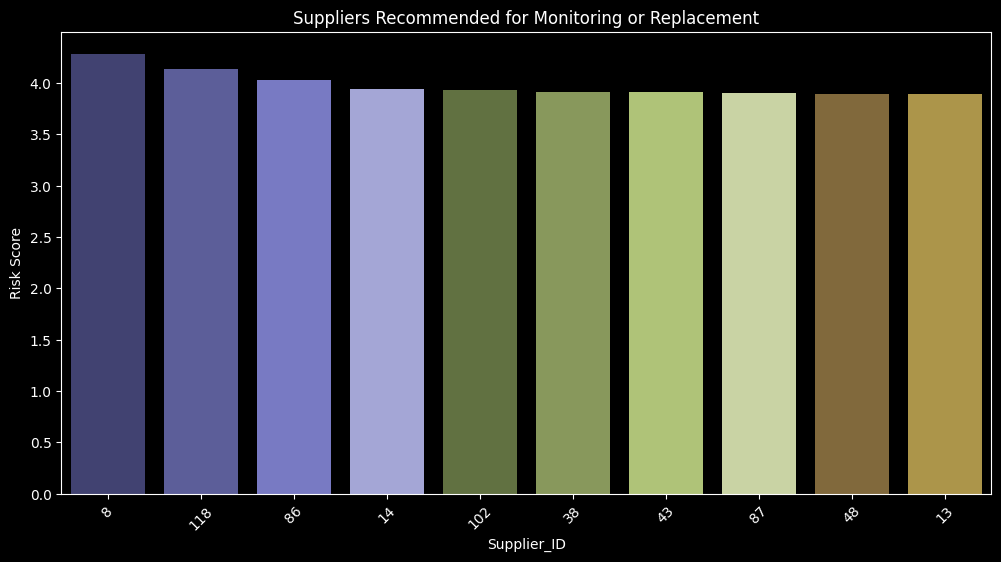

In [584]:
#top15 = supplier_score.head(15)
top15 = supplier_score.sort_values(by="Risk_Score",ascending=False).head(10)
plt.figure(figsize=(12,6))

sns.barplot(
    x=top15["Supplier_ID"].astype(str),
    y=top15["Risk_Score"],
    palette="tab20b",
)


plt.xticks(rotation=45)
plt.xlabel("Supplier_ID")
plt.ylabel("Risk Score")
plt.title("Suppliers Recommended for Monitoring or Replacement")
plt.show()

##### Observation:
* Supplier 8 has the highest risk score (~4.3), followed by Supplier 118 and Supplier 86, with all listed suppliers scoring high (around 4.0 or above).

##### Insight:
* These suppliers consistently pose operational risks to the supply chain due to a combination of delivery delays, long lead times, or stock-out rates.

##### Recommendation:
* Closely monitor top offenders like Supplier 8 and 118, and prepare backup suppliers in case replacement becomes necessary.

# Q9. Which products have the highest demand?
- Problem:
- The business treats all products similarly, causing high-demand products to run out of stock while low-demand products occupy warehouse space.

C:\Users\richa\AppData\Local\Temp\ipykernel_2224\3670137954.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


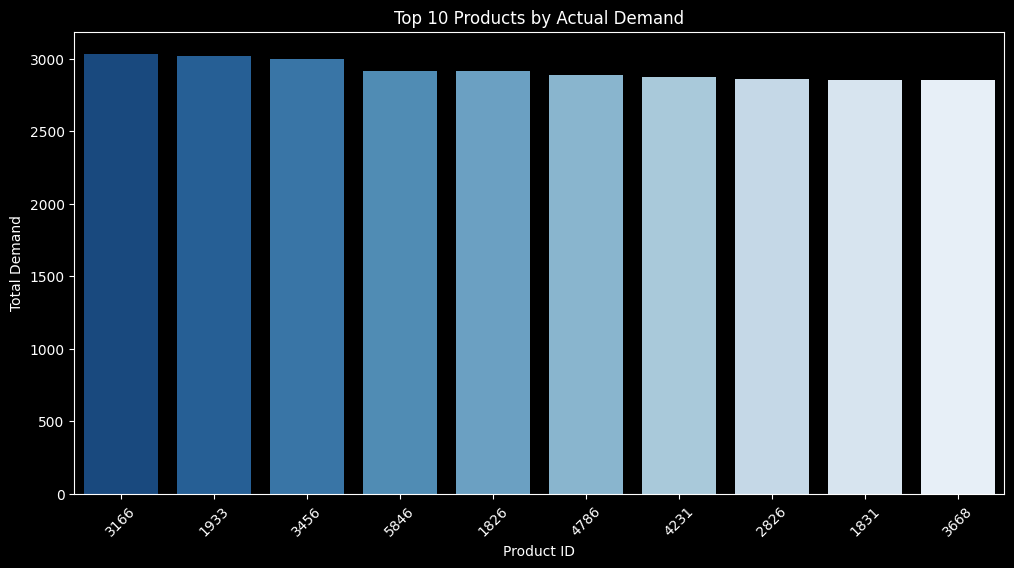

In [586]:
# Calculate top 10 demand products
top_demand = (
    df.groupby("Product_ID")["Actual_Demand"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
    .head(10)
)

# Plotting
plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_demand,
    x="Product_ID",
    y="Actual_Demand",
    order=top_demand["Product_ID"],
    palette="Blues_r",
)
plt.title("Top 10 Products by Actual Demand")
plt.xlabel("Product ID")
plt.ylabel("Total Demand")
plt.xticks(rotation=45)
plt.show()

##### Observation:
* Product ID 3166 leads with the highest demand (3,034 units), followed by Product ID 1933 (3,017 units), with all top 10 products exceeding 2,850 units in sales demand.

##### Insight:
* Demand is heavily concentrated among these specific top SKUs, making them high-priority revenue drivers that require dedicated stock management.

##### Recommendation:
* Prioritize inventory allocation, higher safety stock buffers, and frequent reorders for these high-demand items to prevent stockouts and lost sales.
*

# Q10. Which categories are growing the fastest?


In [469]:
category_growth = (
    df.groupby(["Month","Category"])[["Actual_Demand"]]
      .sum()
      .reset_index()
)

category_growth.head()

,Month,Category,Actual_Demand
0,1,Beverages,115437
1,1,Dairy,113208
2,1,Electronics,114809
3,1,Frozen,117039
4,1,Household,115349


* Frozen products recorded the highest demand in Month 1 (117,039 units).
* Dairy had the lowest demand among the listed categories (113,208 units).
* Demand across all categories is relatively similar (around 113K–117K), suggesting there is no major imbalance in customer demand during Month 1.
* At the beginning of the observed period, inventory requirements appear fairly evenly distributed across categories.

The company should maintain balanced inventory across all categories initially, while giving slightly higher stocking priority to the Frozen category because it experienced the highest demand in Month 1.

In [471]:
growth = (
    category_growth.pivot(index="Month",
                          columns="Category",
                          values="Actual_Demand")
)

growth.pct_change()

Category,Beverages,Dairy,Electronics,Frozen,Household,Personal Care,Snacks
Month,,,,,,,
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,-0.121625,-0.082680,-0.091282,-0.114261,-0.097175,-0.034781,-0.023748
3,0.120270,0.115582,0.107209,0.090579,0.128702,0.009570,-0.015850
4,-0.001232,-0.035546,-0.022880,0.007589,-0.063202,-0.023156,-0.010501
5,0.009766,0.013774,0.013812,0.010929,0.033538,0.092828,0.065141
6,-0.014447,0.002119,-0.053185,-0.022751,-0.043644,-0.063955,-0.042526
7,0.029503,0.033574,0.056957,0.008166,0.052949,0.035538,0.042334
8,-0.031255,-0.021658,0.030406,-0.019743,-0.003874,-0.022946,-0.015381
9,-0.033614,-0.049006,-0.060637,-0.005206,0.005195,0.033470,-0.019110


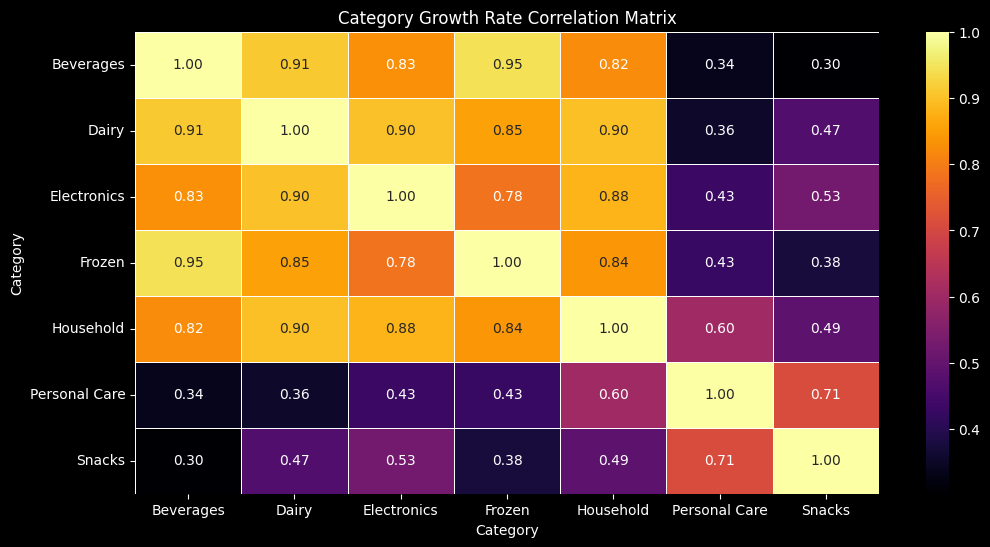

In [588]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate correlation matrix on growth percentage change
growth_pct = growth.pct_change().dropna()
corr_matrix = growth_pct.corr()

# Plot Heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(corr_matrix, annot=True, cmap="inferno", fmt=".2f", linewidths=0.5)
plt.title("Category Growth Rate Correlation Matrix")
plt.show()

Key Findings

The month-over-month growth analysis shows that demand varies across different product categories.
Categories such as Household, Dairy, and Electronics experience strong positive growth in some months, indicating increasing customer demand.
Some categories also show negative growth during certain months, which indicates fluctuations in demand rather than consistent growth.


* Positive values (0.05) = demand increased by 5%
* Negative values (-0.03) = demand decreased by 3%
* Month 1 is NaN because there is no previous month for comparison.



#### Category   	Highest Monthly Growth
* Household	12.87% (Month 3)
* Beverages	12.03% (Month 3)
* Dairy	11.56% (Month 3)
* Electronics	10.72% (Month 3)
* Snacks	10.09% (Month 10)
* Personal Care	9.28% (Month 5)
* Frozen	9.06% (Month 3)

# Q11. How does demand vary by month?


In [592]:
monthly_demand

,Actual_Demand
Month_name,
January,802780
February,737677
March,795145
April,777968
May,804165
June,776642
July,805221
August,795456
September,780488


C:\Users\richa\AppData\Local\Temp\ipykernel_2224\3258750763.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


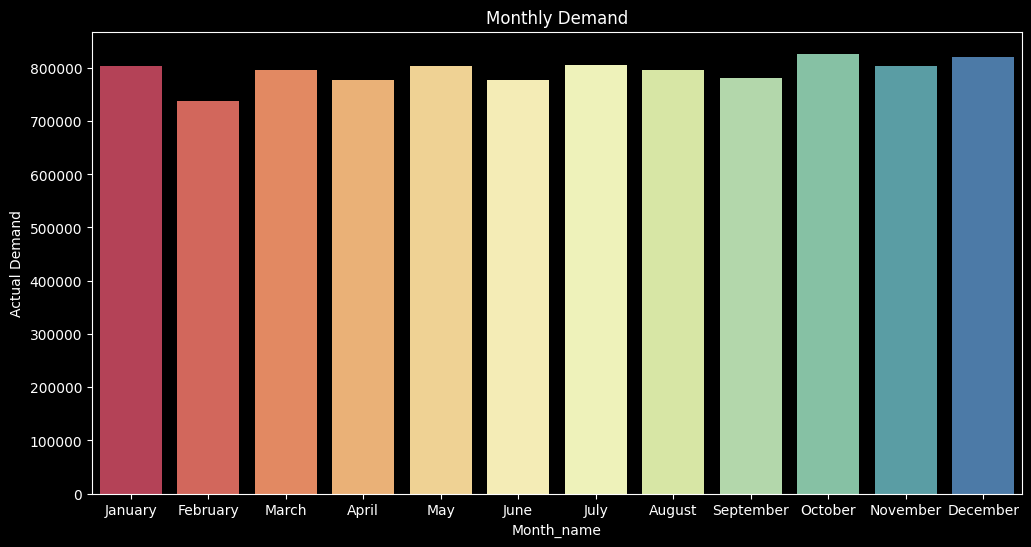

In [606]:
df["Month_name"] = df["Date"].dt.month_name()

monthly_demand = (
    df.groupby("Month_name")[["Actual_Demand"]]
      .sum()
      .reindex([
          "January","February","March","April","May","June",
          "July","August","September","October","November","December"
      ])
)
plt.figure(figsize=(12, 6))

sns.barplot(
    x=monthly_demand.index,
    y=monthly_demand["Actual_Demand"],
    palette="Spectral"
)
#monthly_demand.plot(kind="bar", figsize=(8,5))
plt.title("Monthly Demand")
plt.ylabel("Actual Demand")
plt.show()

##### Observation:
* Monthly demand shows a steady overall upward trend throughout the year, starting at its lowest point in February (~750,000 units) and peaking during the fourth quarter (October to December) near 900,000 units.

##### Insight:
* Customer demand stays consistently high year-round with gradual growth, experiencing its strongest peak in the final months of the year.

##### Recommendation:
* Increase warehouse stock capacity and procurement volume starting in late Q3 to prepare for peak year-end sales, while avoiding over-stocking in lower-demand months like February.
*

# Q12. How do promotions impact customer demand?


In [478]:
promotion = (
    df.groupby("Promotion_Flag")[["Actual_Demand"]]
      .mean()
      .reset_index()
)

promotion

,Promotion_Flag,Actual_Demand
0,0,44.892820
1,1,63.052013


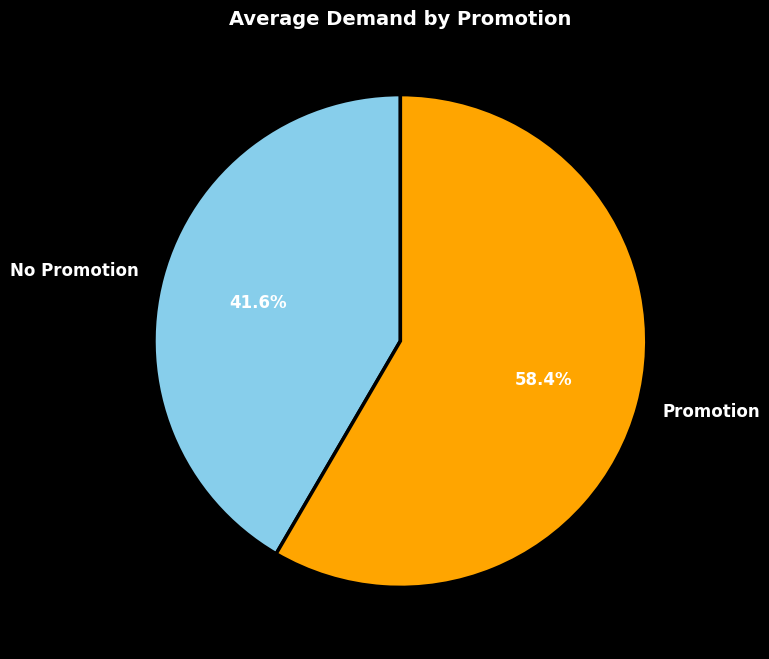

In [612]:
plt.figure(figsize=(8,8))

plt.pie(
    promotion["Actual_Demand"],
    wedgeprops={"linewidth":2.5,"edgecolor":"black"},
    labels=["No Promotion", "Promotion"],
    colors=["skyblue", "orange"],  
    autopct="%1.1f%%",
    startangle=90,textprops={"fontsize":12, "fontweight":"bold"},
)

plt.title("Average Demand by Promotion",fontsize=14,
    fontweight="bold")
plt.show()

##### Observation:
* Promotional periods account for 58.4% of average demand, compared to 41.6% during non-promotional periods.

##### Insight:
* Marketing campaigns and promotional offers successfully drive higher consumer demand, creating a noticeable sales uplift.

##### Recommendation:
* Strategically align inventory replenishment schedules with upcoming marketing campaigns to ensure adequate stock levels during promotional pushes.
*

# Q13. How do holidays affect inventory consumption?


In [482]:
holiday = (
    df.groupby("Holiday_Flag")[["Units_Sold"]]
      .sum()
      .reset_index()
)

holiday

,Holiday_Flag,Units_Sold
0,0,9162425
1,1,349321


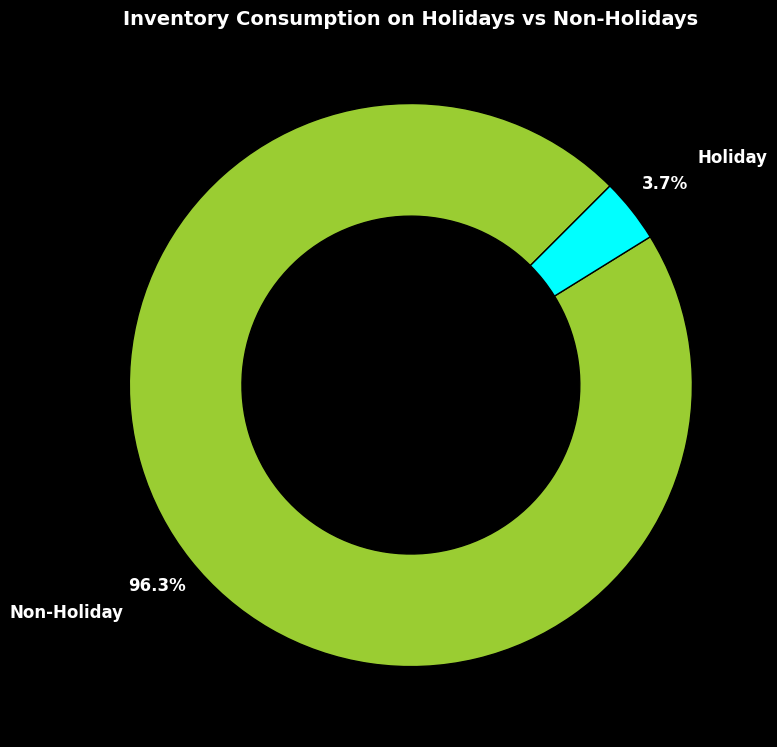

In [620]:
colors = ["yellowgreen", "cyan"]  # Blue, Orange

plt.figure(figsize=(8,8))

plt.pie(
    holiday["Units_Sold"],
    labels=["Non-Holiday", "Holiday"],
    colors=colors,
    autopct="%1.1f%%",
    startangle=45,
    wedgeprops=dict(width=0.4, edgecolor="black"),
    pctdistance=1.15,
    labeldistance=1.30,
    textprops={"fontsize":12, "fontweight":"bold"}
)

plt.title(
    "Inventory Consumption on Holidays vs Non-Holidays",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

##### Observation:
* The vast majority of inventory consumption (96.3%) occurs on non-holidays, with holidays accounting for only a very small fraction (3.7%).

##### Insight:
* Holidays do not drive significant stock usage, meaning that regular, everyday sales are the primary driver of your inventory depletion.

##### Recommendation:
* Focus your inventory planning and restocking efforts around regular daily demand patterns, and avoid unnecessarily overstocking items just because a holiday is approaching.
*

# Model Training and Evaluation

# Q14. Can we forecast future product demand?
### Client Problem:-Can we estimate the demand of each product in the coming days or weeks?

In [487]:
df.select_dtypes(include="object").columns

Index(['Category', 'Month_name'], dtype='object')

In [488]:
df["Category"].unique()

array(['Frozen', 'Personal Care', 'Household', 'Beverages', 'Electronics',
       'Dairy', 'Snacks'], dtype=object)

In [489]:
le = LabelEncoder()
df["Category"] = le.fit_transform(df["Category"])

In [490]:
features = [
    "Warehouse_ID",
    "Product_ID",
    "Category",
    "Opening_Stock",
    "Units_Received",
    "Lead_Time_Days",
    "Supplier_Delay_Days",
    "Reorder_Level",
    "Safety_Stock",
    "Purchase_Cost",
    "Selling_Price",
    "Promotion_Flag",
    "Holiday_Flag",
    "Temperature_C",
    "Demand_Forecast",
    "Year",
    "Month",
    "Day",
    "DayOfWeek",
    "Quarter",
    "WeekOfYear"
]

X = df[features]

y = df["Actual_Demand"]

In [491]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Applying Linear Regression model

In [493]:

# Create model
lr_model = LinearRegression()

# Train
lr_model.fit(X_train, y_train)

# Prediction
lr_pred = lr_model.predict(X_test)

# Evaluation
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = mean_squared_error(y_test, lr_pred, squared=False)
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression Results")
print("-"*35)
print(f"MAE : {lr_mae:.2f}")
print(f"RMSE: {lr_rmse:.2f}")
print(f"R² Score: {lr_r2:.4f}")
print(f"Accuracy: {lr_r2*100:.2f}%")

Linear Regression Results
-----------------------------------
MAE : 4.46
RMSE: 5.76
R² Score: 0.8264
Accuracy: 82.64%


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


##  Applying Random Forest Regressor

In [495]:
# Create Model
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

# Train Model
rf_model.fit(X_train, y_train)

# Predict
rf_pred = rf_model.predict(X_test)

# Evaluation
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = mean_squared_error(y_test, rf_pred) ** 0.5
rf_r2 = r2_score(y_test, rf_pred)

# Print Results
print("="*50)
print("Random Forest Regressor Performance")
print("="*50)

print(f"MAE       : {rf_mae:.4f}")
print(f"RMSE      : {rf_rmse:.4f}")
print(f"R² Score  : {rf_r2:.4f}")

print("="*50)

Random Forest Regressor Performance
MAE       : 4.4872
RMSE      : 5.7522
R² Score  : 0.8266


## Applying XGBoost

In [497]:
xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    objective='reg:squarederror',
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)


mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)
accuracy = r2 * 100
print("MAE :", mae)
print("RMSE:", rmse)
print("R² Score:", r2)
print(f"Model Accuracy: {accuracy:.2f}%")

MAE : 4.474154245877266
RMSE: 5.738963599136545
R² Score: 0.8274173736572266
Model Accuracy: 82.74%


## Model Comparison

In [499]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        lr_mae,
        rf_mae,
        mae
    ],
    "RMSE": [
        lr_rmse,
        rf_rmse,
        rmse
    ],
    "R² Score": [
        lr_r2,
        rf_r2,
        r2
    ]
})

comparison["Accuracy (%)"] = comparison["R² Score"] * 100

comparison = comparison.sort_values(
    by="R² Score",
    ascending=False
)

comparison

,Model,MAE,RMSE,R² Score,Accuracy (%)
2,XGBoost,4.474154,5.738964,0.827417,82.741737
1,Random Forest,4.487244,5.752207,0.826620,82.662000
0,Linear Regression,4.462662,5.755269,0.826435,82.643534


##### Observation:
* All three models perform very well and closely together, with XGBoost slightly outperforming the others by achieving the highest R² score (0.827) and accuracy (~82.74%), as well as the lowest RMSE (5.74).

##### Insight:
* Product demand can indeed be forecasted effectively; XGBoost captures non-linear demand patterns best, making errors slightly smaller compared to Random Forest and Linear Regression.

##### Recommendation:
* Deploy the XGBoost model into production for estimating future demand, while using its predictions to dynamically plan inventory restocking and reduce stockout risks.

In [622]:
forecast = X_test.copy()

forecast["Product_ID"] = df.loc[X_test.index, "Product_ID"]
forecast["Predicted_Demand"] = y_pred

top10 = (
    forecast.groupby("Product_ID")["Predicted_Demand"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

print(top10)

Product_ID
5730    80.684448
5026    65.673950
2974    65.295120
5216    65.195160
2529    64.779259
4302    64.535347
5756    64.190071
3126    63.157337
1209    63.027691
5941    62.934212
Name: Predicted_Demand, dtype: float32


C:\Users\richa\AppData\Local\Temp\ipykernel_2224\1051546099.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(top10,palette="Oranges_r")


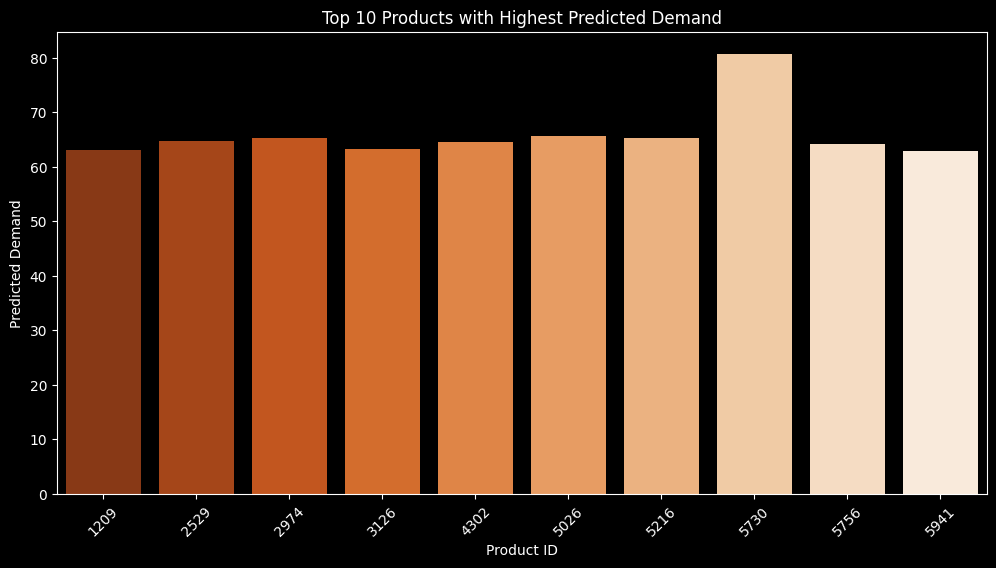

In [628]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
sns.barplot(top10,palette="Oranges_r")
plt.title("Top 10 Products with Highest Predicted Demand")
plt.xlabel("Product ID")
plt.ylabel("Predicted Demand")
plt.xticks(rotation=45)
plt.show()

##### Observation:
* Product ID 5730 has the highest predicted demand (around 80 units), while the remaining top 9 products show a very consistent predicted demand between 60 to 65 units.

##### Insight:
* Product 5730 stands out as the primary high-demand SKU, while demand across the rest of the top products is evenly distributed, indicating stable baseline sales for these key items.

##### Recommendation:
* Ensure priority restocking and a higher safety stock buffer specifically for Product 5730, while maintaining steady replenishment cycles for the other top-performing products.


# Q15.Can we predict inventory shortages before they happen?
#### Client Problem- Most companies discover a stock shortage only after customers start placing orders and the product is already unavailable. By then, sales are already lost."


In [505]:
df["Inventory_Shortage"] = (
    df["Closing_Stock"] <= df["Safety_Stock"]
).astype(int)

In [667]:
q15_features = [
    "Warehouse_ID",
    "Product_ID",
    "Category",
    "Opening_Stock",
    "Units_Received",
    "Units_Sold",
    "Lead_Time_Days",
    "Supplier_Delay_Days",
    "Reorder_Level",
    "Safety_Stock",
    "Purchase_Cost",
    "Selling_Price",
    "Promotion_Flag",
    "Holiday_Flag",
    "Temperature_C",
    "Demand_Forecast",
    "Year",
    "Month",
    "Day",
    "DayOfWeek",
    "Quarter",
    "WeekOfYear"
]

q15_X = df[q15_features]

q15_y = df["Inventory_Shortage"]

In [669]:
from sklearn.model_selection import train_test_split

q15_X_train, q15_X_test, q15_y_train, q15_y_test = train_test_split(
    q15_X,
    q15_y,
    test_size=0.2,
    random_state=42,
    stratify=q15_y
)

In [671]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

q15_X_train_scaled = scaler.fit_transform(q15_X_train)
q15_X_test_scaled = scaler.transform(q15_X_test)

# Applying Logistic Regression

In [673]:
q15_lr = LogisticRegression(
    max_iter=2000,
    random_state=42
)

q15_lr.fit(q15_X_train_scaled, q15_y_train)

q15_lr_pred = lr.predict(q15_X_test_scaled)

# Applying Random Forest

In [676]:
q15_rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

q15_rf.fit(q15_X_train, q15_y_train)

q15_rf_pred = q15_rf.predict(q15_X_test)

## Applying XGBoost

In [701]:
q15_xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric="logloss"
)

q15_xgb.fit(q15_X_train, q15_y_train)

q15_xgb_pred = q15_xgb.predict(q15_X_test)

## Model Comparison

In [703]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

results = []

models = {
    "Logistic Regression": (q15_lr, q15_lr_pred),
    "Random Forest": (q15_rf, q15_rf_pred),
    "XGBoost": (q15_xgb, q15_xgb_pred)
}

for name, (model, pred) in models.items():

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(q15_y_test, pred),
        "Precision": precision_score(q15_y_test, pred),
        "Recall": recall_score(q15_y_test, pred),
        "F1 Score": f1_score(q15_y_test, pred),
        "ROC AUC": roc_auc_score(
            q15_y_test,
            model.predict_proba(q15_X_test)[:,1]
        )
    })

comparison = pd.DataFrame(results)

comparison

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.998475,0.985768,0.969072,0.977349,0.506259
1,Random Forest,0.993675,0.972626,0.837261,0.899881,0.999348
2,XGBoost,0.997275,0.965004,0.954345,0.959645,0.999800


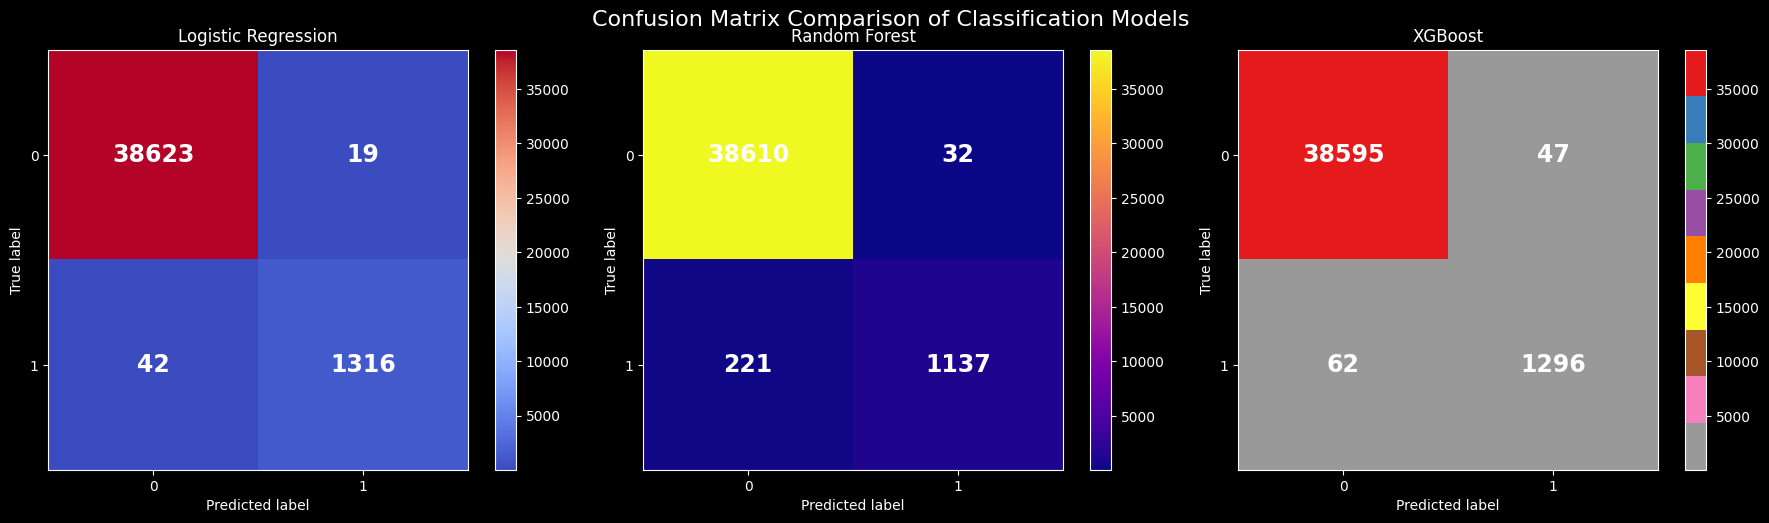

In [725]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Logistic Regression
disp=ConfusionMatrixDisplay.from_estimator(
    q15_lr,
    q15_X_test_scaled,
    q15_y_test,
    cmap="coolwarm",
    ax=axes[0],
    colorbar=True
)
axes[0].set_title("Logistic Regression")
for text in disp.text_.ravel():
    text.set_fontsize(17)
    text.set_fontweight("bold")
    text.set_color("white")   # Optional (works well on dark cells)

# Random Forest
disp=ConfusionMatrixDisplay.from_estimator(
    q15_rf,
    q15_X_test,
    q15_y_test,
    cmap="plasma",
    ax=axes[1],
    colorbar=True
)
axes[1].set_title("Random Forest")
for text in disp.text_.ravel():
    text.set_fontsize(17)
    text.set_fontweight("bold")
    text.set_color("white")   # Optional (works well on dark cells)


# XGBoost
disp=ConfusionMatrixDisplay.from_estimator(
    q15_xgb,
    q15_X_test,
    q15_y_test,
    cmap="Set1_r",
    ax=axes[2],
    colorbar=True
)
axes[2].set_title("XGBoost")

plt.suptitle("Confusion Matrix Comparison of Classification Models", fontsize=16)

plt.tight_layout()

for text in disp.text_.ravel():
    text.set_fontsize(17)
    text.set_fontweight("bold")
    text.set_color("white")   # Optional (works well on dark cells)


plt.show()

##### Observation
* Logistic Regression and XGBoost identified inventory shortages with very few prediction errors, while Random Forest missed more shortage cases.

##### Insight
* XGBoost and Logistic Regression provide more reliable inventory shortage predictions, making them suitable for early shortage detection.

##### Recommendation
* Use XGBoost as the preferred model for predicting inventory shortages, enabling timely inventory replenishment and reducing the risk of stock-outs.

 # Q17 Which products are likely to experience stock-outs?

In [727]:
df["Stockout"] = (df["Closing_Stock"] == 0).astype(int)

In [729]:
df["Stockout"].value_counts()

Stockout
0    198816
1      1184
Name: count, dtype: int64

In [731]:
q17_features = [
    "Warehouse_ID",
    "Product_ID",
    "Category",
    "Opening_Stock",
    "Units_Received",
    "Units_Sold",
    "Lead_Time_Days",
    "Supplier_Delay_Days",
    "Reorder_Level",
    "Safety_Stock",
    "Purchase_Cost",
    "Selling_Price",
    "Promotion_Flag",
    "Holiday_Flag",
    "Temperature_C",
    "Demand_Forecast",
    "Year",
    "Month",
    "Day",
    "DayOfWeek",
    "Quarter",
    "WeekOfYear"
]

q17_X = df[q17_features]
q17_y = df["Stockout"]

In [733]:
from sklearn.model_selection import train_test_split

q17_X_train, q17_X_test, q17_y_train, q17_y_test = train_test_split(
    q17_X,
    q17_y,
    test_size=0.2,
    random_state=42,
    stratify=q17_y
)

## Applying Logistic Regression

In [735]:
from sklearn.linear_model import LogisticRegression

q17_log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

q17_log_model.fit(q17_X_train, q17_y_train)

q17_log_pred = q17_log_model.predict(q17_X_test)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(q17_y_test, q17_log_pred))
print("Precision:", precision_score(q17_y_test, q17_log_pred))
print("Recall   :", recall_score(q17_y_test, q17_log_pred))
print("F1 Score :", f1_score(q17_y_test, q17_log_pred))


Accuracy : 0.999575
Precision: 0.9782608695652174
Recall   : 0.9493670886075949
F1 Score : 0.9635974304068522


## Applying  Random Forest

In [737]:
from sklearn.ensemble import RandomForestClassifier

# Create Model
q17_rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Train Model
q17_rf_model.fit(q17_X_train, q17_y_train)

# Predict Class
q17_rfc_pred = q17_rf_model.predict(q17_X_test)

# Predict Probability
q17_y_prob = q17_rf_model.predict_proba(q17_X_test)[:, 1]


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("="*50)
print("Random Forest Classifier Performance")
print("="*50)

print(f"Accuracy : {accuracy_score(q17_y_test, q17_rfc_pred):.4f}")
print(f"Precision: {precision_score(q17_y_test, q17_rfc_pred):.4f}")
print(f"Recall   : {recall_score(q17_y_test, q17_rfc_pred):.4f}")
print(f"F1 Score : {f1_score(q17_y_test, q17_rfc_pred):.4f}")
print(f"ROC AUC  : {roc_auc_score(q17_y_test, q17_y_prob):.4f}")


Random Forest Classifier Performance
Accuracy : 0.9971
Precision: 0.7027
Recall   : 0.8776
F1 Score : 0.7805
ROC AUC  : 0.9988


## Applying XGBoost 

In [739]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Create Model
q17_xgb_clf_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric="logloss"
)

# Train
q17_xgb_clf_model.fit(q17_X_train, q17_y_train)

# Prediction
q17_xgb_clf_pred = q17_xgb_clf_model.predict(q17_X_test)

# Probability
q17_xgb_clf_prob = q17_xgb_clf_model.predict_proba(q17_X_test)[:,1]

print("="*50)
print("XGBoost Classifier Performance")
print("="*50)

print(f"Accuracy : {accuracy_score(q17_y_test, q17_xgb_clf_pred):.4f}")
print(f"Precision: {precision_score(q17_y_test, q17_xgb_clf_pred):.4f}")
print(f"Recall   : {recall_score(q17_y_test, q17_xgb_clf_pred):.4f}")
print(f"F1 Score : {f1_score(q17_y_test, q17_xgb_clf_pred):.4f}")
print(f"ROC AUC  : {roc_auc_score(q17_y_test, q17_xgb_clf_prob):.4f}")



XGBoost Classifier Performance
Accuracy : 0.9990
Precision: 0.9298
Recall   : 0.8945
F1 Score : 0.9118
ROC AUC  : 0.9998


## Model Comparison

In [741]:
model_comparison = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy":[
        accuracy_score(q17_y_test, q17_log_pred),
        accuracy_score(q17_y_test, q17_rfc_pred),
        accuracy_score(q17_y_test, q17_xgb_clf_pred)
    ],

    "Precision":[
        precision_score(q17_y_test, q17_log_pred),
        precision_score(q17_y_test, q17_rfc_pred),
        precision_score(q17_y_test, q17_xgb_clf_pred)
    ],

    "Recall":[
        recall_score(q17_y_test, q17_log_pred),
        recall_score(q17_y_test, q17_rfc_pred),
        recall_score(q17_y_test, q17_xgb_clf_pred)
    ],

    "F1 Score":[
        f1_score(q17_y_test, q17_log_pred),
        f1_score(q17_y_test, q17_rfc_pred),
        f1_score(q17_y_test, q17_xgb_clf_pred)
    ],

    "ROC AUC":[
        roc_auc_score(q17_y_test, q17_log_model.predict_proba(q17_X_test)[:,1]),
        roc_auc_score(q17_y_test, q17_rf_model.predict_proba(q17_X_test)[:,1]),
        roc_auc_score(q17_y_test, q17_xgb_clf_model.predict_proba(q17_X_test)[:,1])
    ]

})

model_comparison = model_comparison.round(4)

model_comparison = model_comparison.sort_values(
    by="F1 Score",
    ascending=False
)

model_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.9996,0.9783,0.9494,0.9636,1.0000
2,XGBoost,0.9990,0.9298,0.8945,0.9118,0.9998
1,Random Forest,0.9971,0.7027,0.8776,0.7805,0.9988


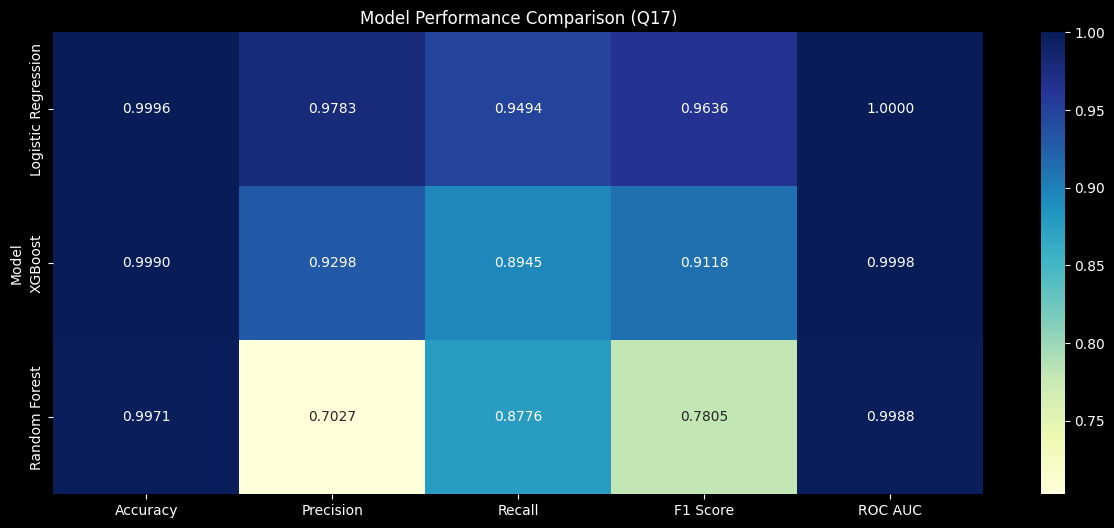

In [747]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

sns.heatmap(
    model_comparison.set_index("Model"),
    annot=True,
    fmt=".4f",
    cmap="YlGnBu"
)

plt.title("Model Performance Comparison (Q17)")
plt.show()

##### Observation
* Logistic Regression achieved the highest performance across all evaluation metrics.
* XGBoost performed nearly as well as Logistic Regression and outperformed Random Forest.
* Random Forest showed comparatively lower Precision and F1-score for stock-out prediction.

##### Insight
* Logistic Regression and XGBoost are more effective in identifying products likely to experience stock-outs with high reliability.
* XGBoost provides strong predictive capability while maintaining excellent overall classification performance.

##### Recommendation
* Deploy Logistic Regression as the primary model for stock-out prediction due to its highest overall performance.
* Use the model predictions to identify high-risk products and replenish inventory before stock-outs occur.
* Continuously monitor model performance and retrain it as new inventory and sales data become available.

## Product with top risk 

In [751]:
log_prob = log_model.predict_proba(X_test_scaled)[:,1]

experience_stockouts = X_test.copy()

experience_stockouts["Actual_Stockout"] = y_test.values
experience_stockouts["Predicted_Stockout"] = log_pred
experience_stockouts["Stockout_Probability"] = log_prob

experience_stockouts.head()

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


,Warehouse_ID,Product_ID,Category,Opening_Stock,Units_Received,Lead_Time_Days,Supplier_Delay_Days,Reorder_Level,Safety_Stock,Purchase_Cost,...,Demand_Forecast,Year,Month,Day,DayOfWeek,Quarter,WeekOfYear,Actual_Stockout,Predicted_Stockout,Stockout_Probability
119737,23,4963,2,205,5,16.0,2.0,109,24,175,...,53.0,2024,6,14,4,2,24,63,0,0.063404
72272,22,1573,3,577,40,2.0,4.0,85,53,195,...,49.0,2025,11,6,3,4,45,53,0,0.167447
158154,12,2861,1,452,132,15.0,0.0,99,64,91,...,52.0,2024,9,26,3,3,39,66,0,0.347891
65426,18,1422,6,214,8,13.0,2.0,149,80,176,...,34.0,2024,1,24,2,1,4,26,0,0.323040
30074,3,5833,2,214,168,2.0,1.0,137,45,139,...,53.0,2025,11,1,5,4,44,58,0,0.526449


In [753]:
top_risk = (
    experience_stockouts
    .groupby("Product_ID")["Stockout_Probability"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_risk

Product_ID
5678    0.986202
5861    0.952411
1134    0.946712
2066    0.928394
4346    0.912250
4288    0.902166
4690    0.896962
2974    0.894725
3100    0.887420
5703    0.881268
Name: Stockout_Probability, dtype: float64

In [755]:
top_risk = (
    experience_stockouts
    .groupby(["Warehouse_ID", "Product_ID"])
    .agg(
        Avg_Stockout_Probability=("Stockout_Probability", "mean"),
        Predicted_Stockout=("Predicted_Stockout", "sum")
    )
    .sort_values(
        by="Avg_Stockout_Probability",
        ascending=False
    )
    .head(10)
)

top_risk

# Predicted_Stockout  -- 1 means "yes"   and 0 means "no"

Avg_Stockout_Probability  Predicted_Stockout
Warehouse_ID Product_ID                                              
14           2138                        0.999250                   0
             4500                        0.999175                   0
17           2208                        0.998825                   0
4            1420                        0.998798                   0
22           5478                        0.998619                   0
15           4500                        0.998409                   0
11           2772                        0.998129                   0
10           2608                        0.998099                   0
8            1633                        0.998006                   0
2            3698                        0.997964                   0

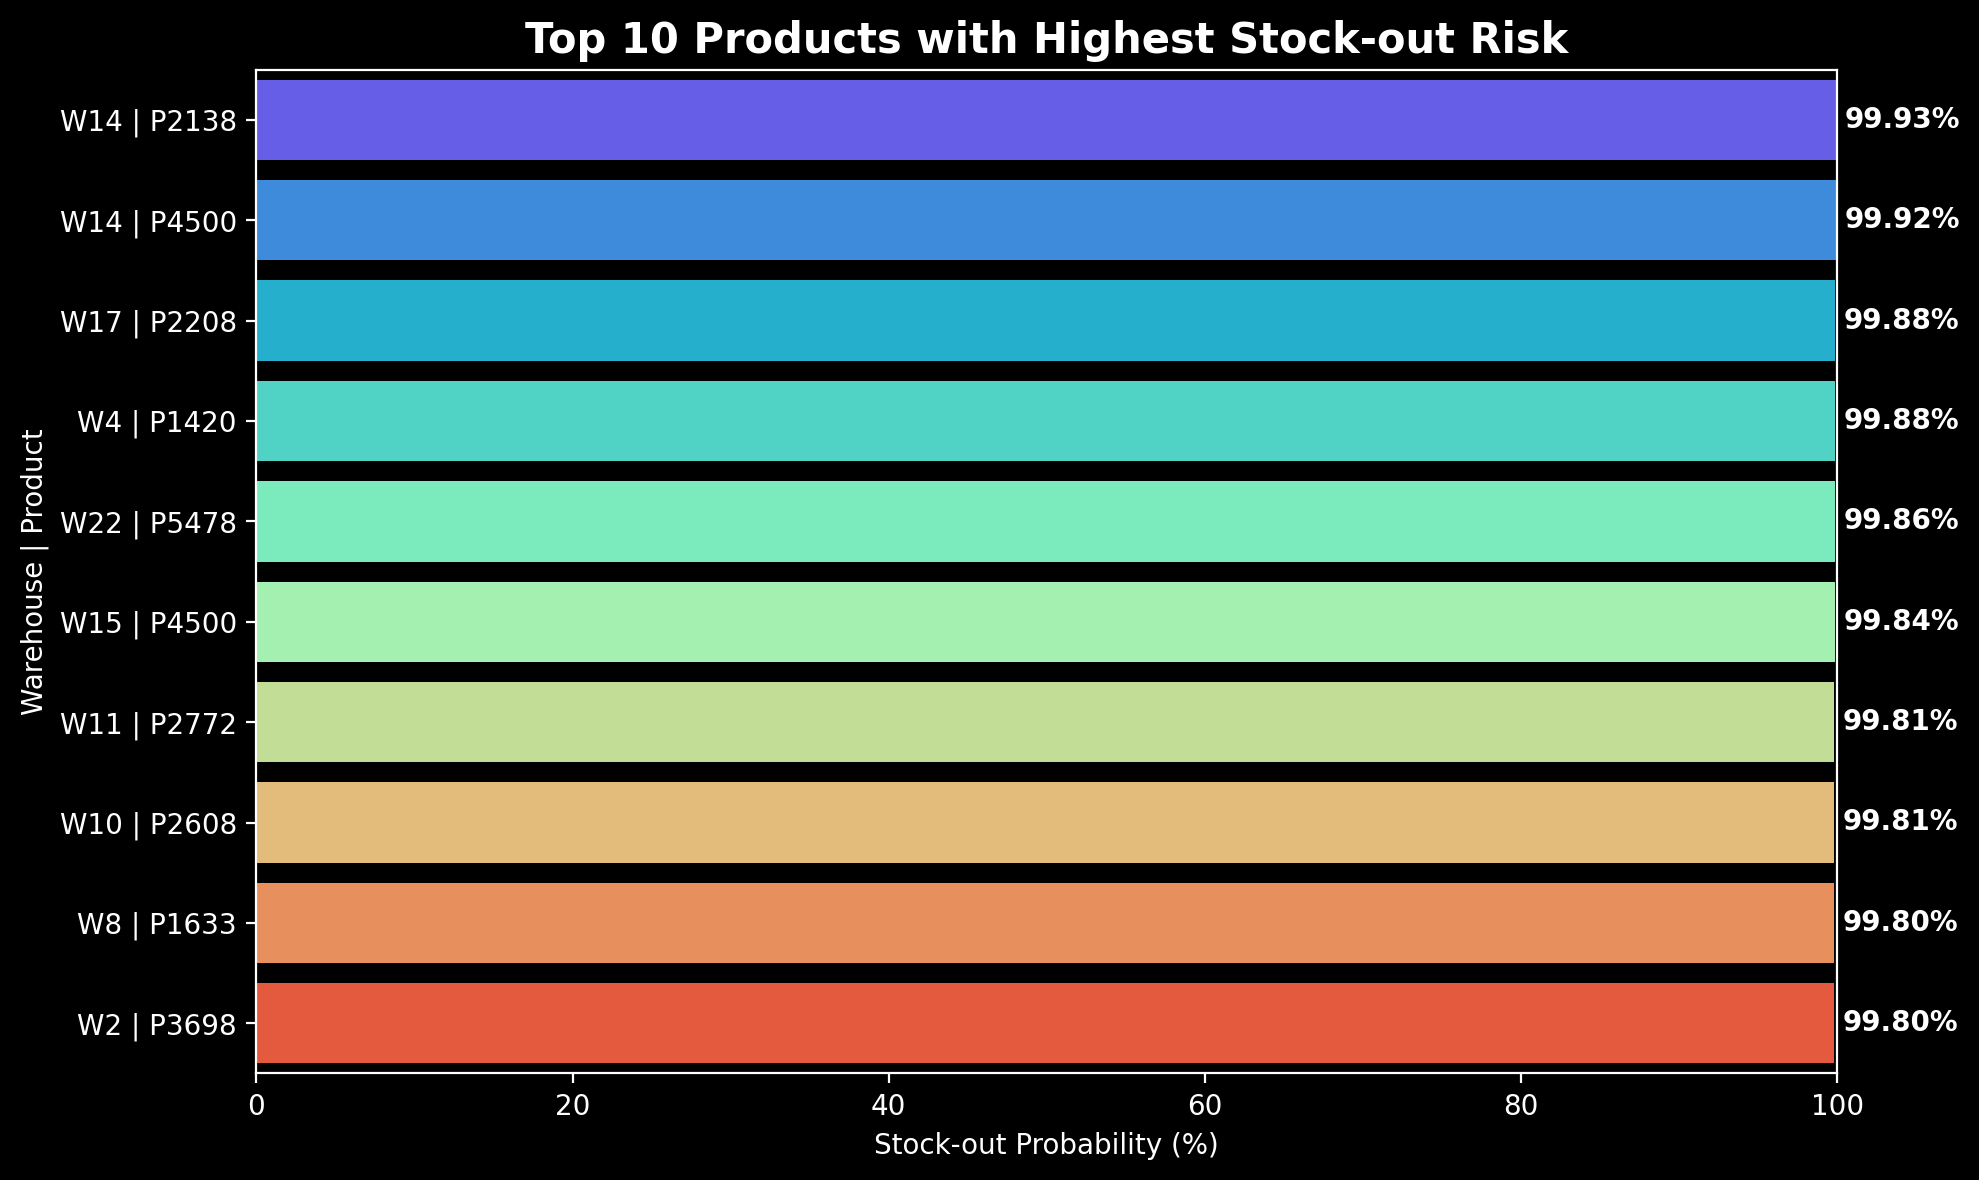

In [759]:
import seaborn as sns
import matplotlib.pyplot as plt

top_risk = top_risk.reset_index()

labels = (
    "W" + top_risk["Warehouse_ID"].astype(str)
    + " | P" +
    top_risk["Product_ID"].astype(str)
)

top_risk["Label"] = labels
top_risk["Probability"] = top_risk["Avg_Stockout_Probability"] * 100

plt.style.use("dark_background")
plt.figure(figsize=(10,6), dpi=200)

ax = sns.barplot(
    data=top_risk,
    y="Label",
    x="Probability",
    hue="Label",          # Different color for each bar
    palette="rainbow",
    legend=False
)

plt.title("Top 10 Products with Highest Stock-out Risk", fontsize=15, fontweight="bold")
plt.xlabel("Stock-out Probability (%)")
plt.ylabel("Warehouse | Product")

# Value labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%", padding=3, fontsize=10, fontweight="bold")

plt.xlim(0,100)
plt.tight_layout()
plt.show()

#### Client Problem :-
* It is impossible for managers to manually monitor thousands of products every day.

##### Our Solution:
* "The AI model identifies products that have the highest probability of running out of stock."

##### Client Benefit
* Managers receive a priority list instead of checking every product. This helps them focus only on products that need immediate attention.

* Using predictive analytics and machine learning, we transformed historical inventory data into actionable business insights. Instead of reacting to stock shortages, your business can now anticipate demand, optimize reorder quantities, identify high-risk products in advance, and improve supplier planning. This leads to lower inventory costs, fewer lost sales, improved customer satisfaction, and better operational efficiency.

# Q16. How much inventory should be reordered next week?

In [761]:
q16_features = [
    "Warehouse_ID",
    "Product_ID",
    "Category",
    "Opening_Stock",
    "Units_Received",
    "Lead_Time_Days",
    "Supplier_Delay_Days",
    "Reorder_Level",
    "Safety_Stock",
    "Purchase_Cost",
    "Selling_Price",
    "Promotion_Flag",
    "Holiday_Flag",
    "Temperature_C",
    "Demand_Forecast",
    "Year",
    "Month",
    "Day",
    "DayOfWeek",
    "Quarter",
    "WeekOfYear"
]

q16_X = df[q16_features]

q16_y = df["Actual_Demand"]

In [763]:
df["Predicted_Demand"] = xgb_model.predict(X)
df["Predicted_Demand"]

0         39.518105
1         45.787876
2         44.917496
3         59.089169
4         55.211914
            ...    
199995    55.830814
199996    29.701429
199997    48.756607
199998    57.982414
199999    37.001549
Name: Predicted_Demand, Length: 200000, dtype: float32

In [765]:
df["Recommended_Reorder"] = (
    (df["Predicted_Demand"] * df["Lead_Time_Days"])
    + df["Safety_Stock"]
    - df["Closing_Stock"]
)


df["Recommended_Reorder"] = (
    df["Recommended_Reorder"]
    .clip(lower=0)
    .round()
    .astype(int)
)

In [767]:
def priority(qty):
    if qty >= 80:
        return "High Priority"
    elif qty >= 40:
        return "Medium Priority"
    elif qty > 0:
        return "Low Priority"
    else:
        return "No Reorder"

df["Priority"] = df["Recommended_Reorder"].apply(priority)

In [769]:
reorder_summary = (
    df[[
        "Product_ID",
        "Predicted_Demand",
        "Closing_Stock",
        "Safety_Stock",
        "Recommended_Reorder",
        "Priority"
    ]]
    .groupby("Product_ID")
    .agg({
        "Predicted_Demand":"mean",
        "Closing_Stock":"mean",
        "Safety_Stock":"mean",
        "Recommended_Reorder":"mean",
        "Priority":"first"
    })
    .reset_index()
)

reorder_summary["Predicted_Demand"] = reorder_summary["Predicted_Demand"].round().astype(int)
reorder_summary["Closing_Stock"] = reorder_summary["Closing_Stock"].round().astype(int)
reorder_summary["Safety_Stock"] = reorder_summary["Safety_Stock"].round().astype(int)
reorder_summary["Recommended_Reorder"] = reorder_summary["Recommended_Reorder"].round().astype(int)

reorder_summary = reorder_summary.sort_values(
    by="Recommended_Reorder",
    ascending=False
)

# reorder_summary.head(10)
reorder_summary["Priority"].value_counts()

Priority
High Priority      2942
No Reorder         1609
Low Priority        235
Medium Priority     214
Name: count, dtype: int64

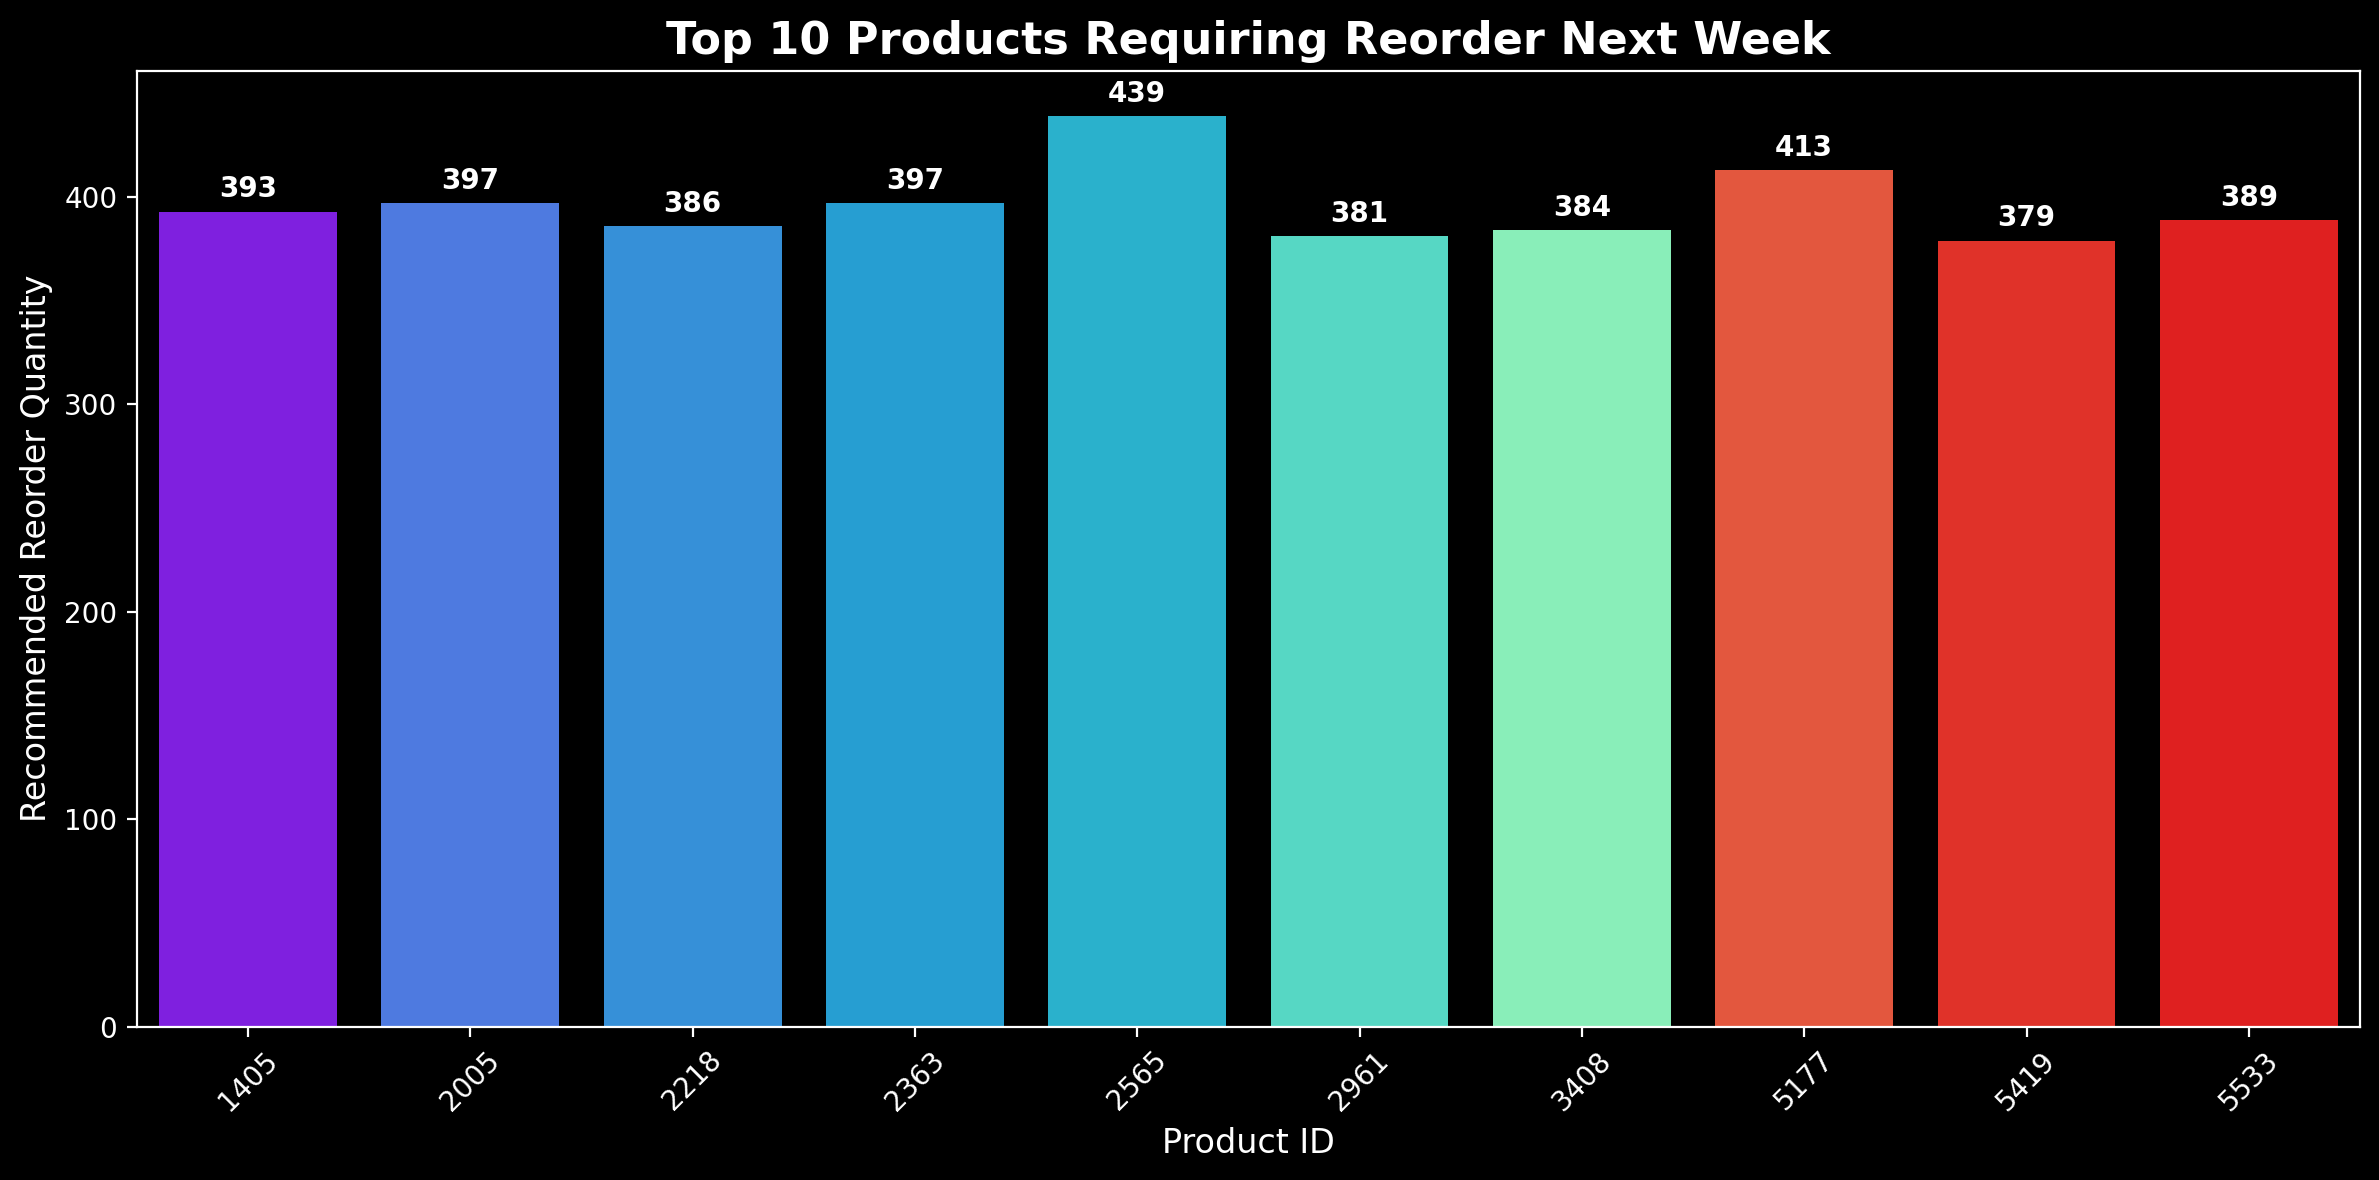

In [771]:
import seaborn as sns
import matplotlib.pyplot as plt

top10 = reorder_summary.head(10)

plt.style.use("dark_background")

plt.figure(figsize=(12,6), dpi=200)

ax = sns.barplot(
    data=top10,
    x="Product_ID",
    y="Recommended_Reorder",
    hue="Product_ID",          # Different color for each bar
    palette="rainbow",         # You can also use "Spectral", "turbo", "viridis"
    legend=False
)

plt.title(
    "Top 10 Products Requiring Reorder Next Week",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Product ID", fontsize=12)
plt.ylabel("Recommended Reorder Quantity", fontsize=12)

# Value labels on top of bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",
        fontsize=10,
        fontweight="bold",
        padding=3
    )

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

##### Observation:
* Product ID 2565 requires the highest reorder quantity (439 units), followed by Product ID 5177 (413 units), with all top 10 products needing substantial restocks between 379 and 439 units next week.

##### Insight:
* Reorder quantities across these top 10 SKUs are consistently high and closely grouped, indicating urgent stock replenishment needs to avoid potential inventory shortages in the upcoming week.

##### Recommendation:
* Issue immediate purchase orders for these 10 SKUs—prioritizing Product ID 2565 and 5177—to ensure stock is delivered before current inventory runs out.